In [ ]:
# 2. Dynamic Bayesian (Hidden Markov model?): Graph-based SLAM
# P(x{t} | e{1:t}) = (alpha) * P(e{t}|x{t}) * P(x{t}|e{1:t})
# P(x{t} | e{1:t-1}) = sum[(P(x{t}|x{t-1}) * P(x{t-1}|e{1:t-1})]

## front-end = graph from raw measurements (z: heavily sensor dependent)
# p(x(1:t), m | z(1:t), u(1:t), x0)
# transition model: p(x{t} | x{t-1}, u{t})
# observation model: p(z{t} | x{t}, m{t}) , note that m -> z is multimodal
# node = pose estimated by u,z; edge = spatial constraints (odom/ aligning observations)
# observation is affected by Gaussian noises and data association is known

## backend = evaluation for most likely configuration; integrated SLAM using statistical test from frontend
# Gaussian approximation
# minimizing log-likelihood of error via 'iterative local linearization'
# what will be information matrix????
# change weights of path and find optimal ones: (z - z(x,u))^T * R^(-1) * (z - z(x,u)))

# create node graph as a map using frontier exploration (implement exploration for GraphSLAM)
# frontier will give highest utility function to unexplored area
# how to walk == dijkstra -- find shortest pathe in weighted graph

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import random
import networkx as nx
from scipy.linalg import solve  # For robust solve if needed

# Parameters
N = 10  # Grid size
sigma_odom = 0.05  # Odometry noise std
sigma_range = 0.1  # Range observation noise std
sigma_bearing = 0.05  # Bearing observation noise std (radians)
max_range = 3.0  # Maximum observation range
num_steps = 30  # Number of navigation steps (may be less if stuck)
seed = 42
np.random.seed(seed)
random.seed(seed)

# 1. Visualize environment: '1' for obstacles, '0' for space
def create_env():
  env = [['0' for _ in range(N)] for _ in range(N)]
  # Add some obstacles for interest
  for col in range(2, 5):
      env[5][col] = '1'
  for row in range(3, 6):
      env[row][7] = '1'
  env[1][1] = '1'
  env[8][8] = '1'

  print("Environment (1 = obstacle, '0' = space):")
  for row in env:
    print(''.join(row))

  return env

env = create_env()



Environment (1 = obstacle, '0' = space):
0000000000
0100000000
0000000000
0000000100
0000000100
0011100100
0000000000
0000000000
0000000010
0000000000


In [ ]:
# True landmark positions (centers of obstacle cells)
landmarks_true = []
for i in range(N):  # row (y)
    for j in range(N):  # col (x)
        if env[i][j] == '1':
            # landmarks_true.append(np.array([j + 0.5, i + 0.5]))  # x, y
            landmarks_true.append(np.array([i, j]))  # x, y
K = len(landmarks_true)
print(f"\nNumber of landmarks (obstacles): {K}")
print("True landmark positions:", landmarks_true)

# 2. Random walk for navigation
# Poses: [x, y] (x horizontal, y vertical downward in grid)
current = np.array([0, 0])  # Start at center of (0,0) cell --> [0.5,0.5]
path_true = [current.copy()]
poses_est = [current.copy()]  # Initial estimates from noisy odometry integration
odometry = []  # List of relative motions u_t: [dx, dy]
observations = [[]]  # obs[t] = list of (landmark_id j, z_r, z_phi)

directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]  # dx, dy: right, left, down, up

for t in range(1, num_steps + 1):
    # Find possible moves (stay in bounds, avoid obstacles)
    possible_moves = []
    curr_i, curr_j = int(current[1]), int(current[0])
    for dx, dy in directions:
        new_j = curr_j + dx
        new_i = curr_i + dy
        if 0 <= new_i < N and 0 <= new_j < N and env[new_i][new_j] == '0':
            possible_moves.append((dx, dy))

    if not possible_moves:
        print(f"Robot stuck after {t-1} steps.")
        break

    # Choose random move
    dx_true, dy_true = random.choice(possible_moves)
    delta_true = np.array([dx_true, dy_true])
    new_true = current + delta_true

    # Noisy odometry measurement u_t
    u = delta_true + np.random.normal(0, sigma_odom, 2)
    odometry.append(u)

    # Update estimated pose (integrate odometry)
    new_est = poses_est[-1] + u
    poses_est.append(new_est)

    # Update true pose
    current = new_true
    path_true.append(current.copy()) # new_true.copy(), actually a poses_true

    # 3. Observations at new pose (frontend: raw measurements to build graph)
    # Assume robot observes all landmarks within max_range, with known association (ID j)
    # z: range r and bearing phi, Gaussian noise
    # Transition model: implicit in odometry u_t, P(x_t | x_{t-1}, u_t)
    # Observation model: multimodal due to multiple landmarks, but Gaussian per obs P(z_t | x_t, m_t)
    obs_t = []
    # derived all reachable measurements at a position
    for j, lm_true in enumerate(landmarks_true):
        dx = lm_true[0] - current[0]
        dy = lm_true[1] - current[1]
        dist_true = np.sqrt(dx**2 + dy**2)
        if 0 < dist_true <= max_range: # sensor limitations
            phi_true = np.arctan2(dy, dx)
            z_r = dist_true + np.random.normal(0, sigma_range) # linear
            z_phi = phi_true + np.random.normal(0, sigma_bearing) # rotate
            # Wrap bearing to [-pi, pi] for stability
            z_phi = (z_phi + np.pi) % (2 * np.pi) - np.pi
            obs_t.append((j, z_r, z_phi))
    observations.append(obs_t)

# Trim to actual steps performed
T = len(path_true) - 1  # Number of moves
path_true = path_true[:T+1]
poses_est = poses_est[:T+1]
odometry = odometry[:T]
observations = observations[:T+1]
print(f"Performed {T} steps in random walk.")
print(f"Path true: {path_true},\nposes_est: {poses_est}, \nodom: {odometry}, \nobservations: {observations}")

# Initialize landmark estimates (from first observation, transformed to global via current est pose)
landmarks_init = [None] * K
for t in range(1, T+1):
    px, py = poses_est[t]
    for j, z_r, z_phi in observations[t]:
        if landmarks_init[j] is None:
            # Initial guess: estimated pose + measured relative in Cartesian
            mx_init = px + z_r * np.cos(z_phi) # map x
            my_init = py + z_r * np.sin(z_phi) # map y
            landmarks_init[j] = np.array([mx_init, my_init])

# Fallback for unseen landmarks (rare, but set to grid center)
for j in range(K):
    if landmarks_init[j] is None:
        landmarks_init[j] = np.array([N/2.0, N/2.0])

print("Initial landmark estimates:", landmarks_init)



Number of landmarks (obstacles): 8
True landmark positions: [array([1, 1]), array([3, 7]), array([4, 7]), array([5, 2]), array([5, 3]), array([5, 4]), array([5, 7]), array([8, 8])]
Performed 30 steps in random walk.
Path true: [array([0, 0]), array([1, 0]), array([2, 0]), array([2, 1]), array([2, 2]), array([1, 2]), array([2, 2]), array([1, 2]), array([1, 3]), array([2, 3]), array([3, 3]), array([3, 2]), array([4, 2]), array([5, 2]), array([6, 2]), array([5, 2]), array([4, 2]), array([5, 2]), array([4, 2]), array([4, 1]), array([3, 1]), array([3, 0]), array([3, 1]), array([3, 2]), array([4, 2]), array([3, 2]), array([3, 1]), array([3, 2]), array([3, 3]), array([2, 3]), array([1, 3])],
poses_est: [array([0, 0]), array([ 1.02483571, -0.00691322]), array([ 2.01312804, -0.01862006]), array([1.98965432, 1.00850794]), array([2.00175243, 1.91284393]), array([0.95635123, 1.84222874]), array([1.95972764, 1.77099133]), array([0.92969571, 1.75640665]), array([0.92902084, 2.7035211 ]), array([1.9

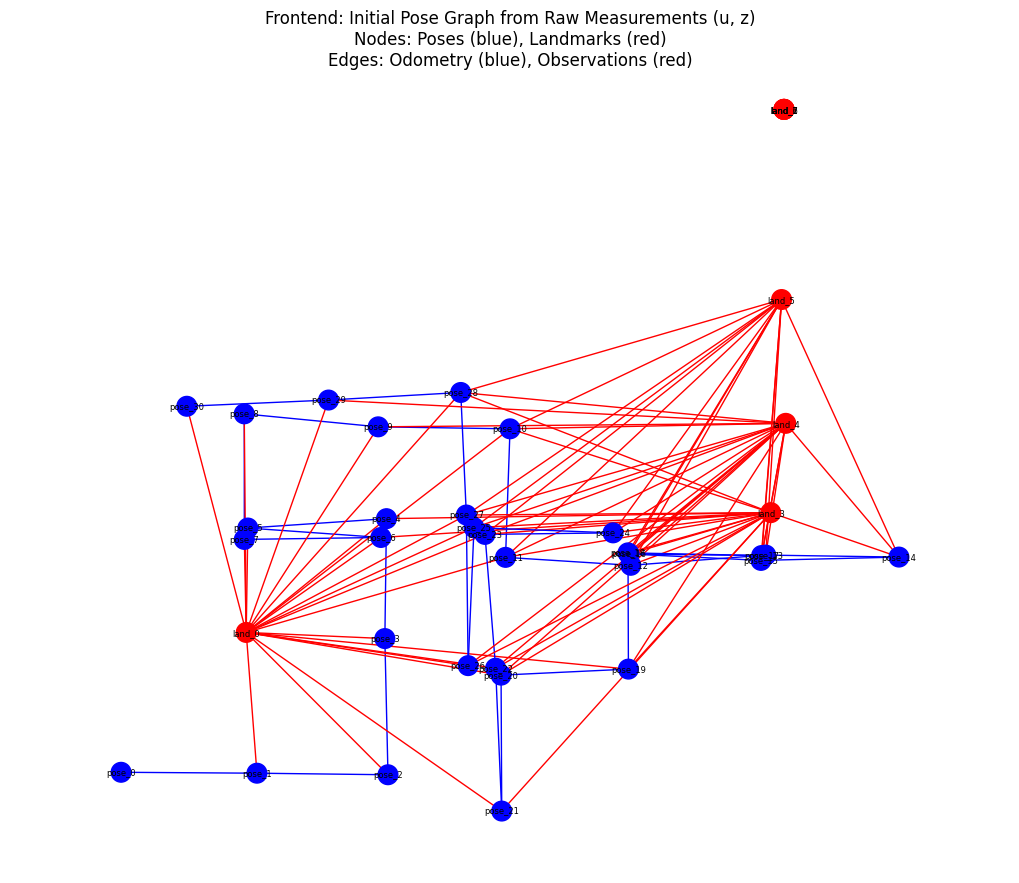

In [ ]:

# 3. Create graph from raw measurements (frontend)
# Nodes: poses (estimated by u, z); edges: odom (spatial from u), obs (aligning z)
# Here, we build a graph for visualization; constraints used in backend
G_init = nx.Graph()
# Add pose nodes (blue)
for t in range(T+1):
    G_init.add_node(f'pose_{t}', type='pose', pos=poses_est[t])
# Add landmark nodes (red)
for j in range(K):
    G_init.add_node(f'land_{j}', type='landmark', pos=landmarks_init[j])
# Odometry edges (blue, between consecutive poses)
for t in range(1, T+1):
    G_init.add_edge(f'pose_{t-1}', f'pose_{t}', type='odom')
# Observation edges (red, pose to landmark)
for t in range(1, T+1):
    for j, _, _ in observations[t]:
        G_init.add_edge(f'pose_{t}', f'land_{j}', type='obs')

# Visualize initial graph
plt.figure(figsize=(10, 8))
pos_init = nx.get_node_attributes(G_init, 'pos')
node_colors = ['blue' if G_init.nodes[n]['type'] == 'pose' else 'red' for n in G_init.nodes]
nx.draw(G_init, pos_init, with_labels=True, node_color=node_colors, node_size=200,
        font_size=6, edge_color=['blue' if G_init[u][v]['type']=='odom' else 'red' for u,v in G_init.edges],
        width=1)
plt.title("Frontend: Initial Pose Graph from Raw Measurements (u, z)\nNodes: Poses (blue), Landmarks (red)\nEdges: Odometry (blue), Observations (red)")
plt.axis('equal')
plt.show()


Running backend optimization with Taylor series / Gauss-Newton...
Singular matrix at iteration 1: Matrix is singular.
Final cost: 15631.77


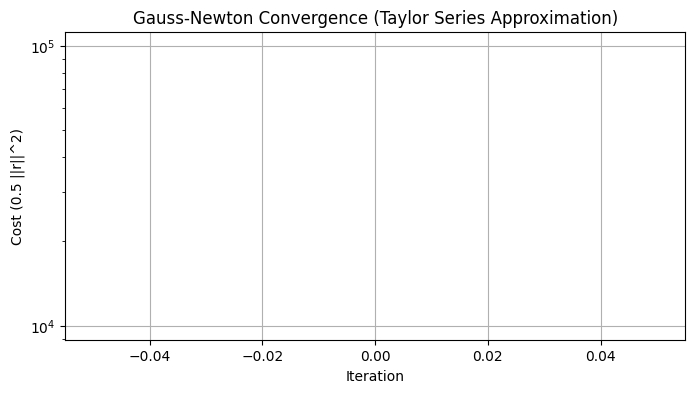

Optimized poses (first 5): [array([0, 0]), array([ 1.02483571, -0.00691322]), array([ 2.01312804, -0.01862006]), array([1.98965432, 1.00850794]), array([2.00175243, 1.91284393])]
Optimized landmarks: [array([0.94383032, 1.05476981]), array([5., 5.]), array([5., 5.]), array([4.90011151, 1.95838776]), array([5.01319784, 2.63187526]), array([4.98182444, 3.56572391]), array([5., 5.]), array([5., 5.])]


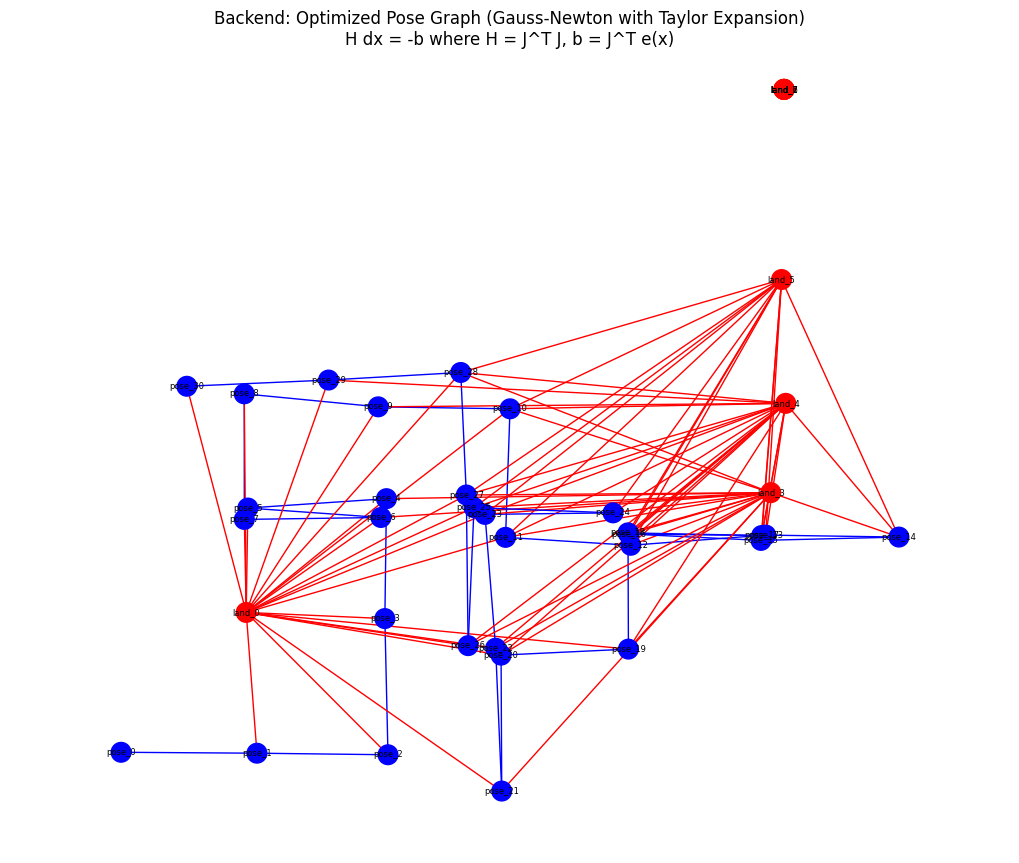

In [ ]:

# 4. Backend: Find most probable pose (and map) configuration using Taylor series / Gauss-Newton
# p(x_{1:T}, m | z_{1:T}, u_{1:T}, x_0) via Gaussian approximation
# Minimize negative log-likelihood: sum errors (Gaussian) via iterative local linearization
# Taylor: e(x + dx) ≈ e(x) + J dx
# Leads to H dx = -b with H = J^T J (approx Hessian), b = J^T e(x)
# Information matrix: approx Hessian from constraints (weights via 1/sigma^2 in scaled residuals)
# Weights: path (odom) and obs weighted by 1/sigma; optimal via minimization
# Fix pose_0 for gauge freedom

# Compute total number of observations for sizing
total_obs_count = sum(len(observations[t]) for t in range(1, T+1))
num_res = 2 * T + 2 * total_obs_count
var_size = 2 * T + 2 * K

def residuals(x):
    """Stacked residuals: odom errors + obs errors, scaled by 1/sigma (info weights)"""
    res = np.zeros(num_res)
    row = 0
    # Fixed pose 0
    px_prev, py_prev = 0.5, 0.5
    # Odometry errors: linear constraints from transition model p(x_t | x_{t-1}, u_t)
    for ti in range(1, T+1):
        idx = 2 * (ti - 1)
        px_t, py_t = x[idx:idx+2]
        u = odometry[ti-1]
        # Error: (x_t - x_{t-1} - u), weighted
        res[row] = (px_t - px_prev - u[0]) / sigma_odom
        res[row + 1] = (py_t - py_prev - u[1]) / sigma_odom
        row += 2
        px_prev, py_prev = px_t, py_t

    # Observation errors: from p(z_t | x_t, m), nonlinear h(x_t, m) = (r, phi)
    offset = 2 * T
    for t in range(1, T+1):
        idx_t = 2 * (t - 1)
        px_t, py_t = x[idx_t:idx_t+2]
        for j, z_r, z_phi in observations[t]:
            idx_m = offset + 2 * j
            mx, my = x[idx_m:idx_m+2]
            dx = mx - px_t
            dy = my - py_t
            pred_r = np.sqrt(dx**2 + dy**2)
            if pred_r < 1e-6:
                pred_r = 1e-6  # Avoid div0
            pred_phi = np.arctan2(dy, dx)
            # Error: (z - pred), weighted; phi wrapped but small noise ok
            res[row] = (z_r - pred_r) / sigma_range
            res[row + 1] = (z_phi - pred_phi) / sigma_bearing
            row += 2
    return res

def compute_jacobian(x):
    """Analytical Jacobian of residuals wrt variables (poses 1:T, landmarks)"""
    J = np.zeros((num_res, var_size))
    row = 0
    # Odom Jacobian: linear
    px_prev, py_prev = 0.5, 0.5  # Fixed, but update for chaining
    for ti in range(1, T+1):
        idx_t = 2 * (ti - 1)
        px_t, py_t = x[idx_t:idx_t+2]

        # x residual row
        if ti == 1:
            J[row, idx_t] = 1.0 / sigma_odom
        else:
            idx_prev = 2 * (ti - 2)
            J[row, idx_prev] = -1.0 / sigma_odom
            J[row, idx_t] = 1.0 / sigma_odom
        row += 1

        # y residual row
        if ti == 1:
            J[row, idx_t + 1] = 1.0 / sigma_odom
        else:
            idx_prev = 2 * (ti - 2)
            J[row, idx_prev + 1] = -1.0 / sigma_odom
            J[row, idx_t + 1] = 1.0 / sigma_odom
        row += 1

        px_prev, py_prev = px_t, py_t

    # Obs Jacobian: nonlinear
    offset = 2 * T
    for t in range(1, T+1):
        idx_t = 2 * (t - 1)
        px_t, py_t = x[idx_t:idx_t+2]
        for jj, z_r, z_phi in observations[t]:
            idx_m = offset + 2 * jj
            mx, my = x[idx_m:idx_m+2]
            dx_ = mx - px_t  # dx for derivs
            dy_ = my - py_t
            r_pred = np.sqrt(dx_**2 + dy_**2)
            if r_pred < 1e-6:
                r_pred = 1e-6  # Avoid div0
                dx_over_r2 = 0
                dy_over_r2 = 0
            else:
                dx_over_r2 = dx_ / r_pred**2
                dy_over_r2 = dy_ / r_pred**2

            dr_over_r = 1.0 / r_pred  # For range partials: dx / (r * sigma)

            # Range residual row
            J[row, idx_t] = (dx_ * dr_over_r) / sigma_range  # partial / px_t
            J[row, idx_t + 1] = (dy_ * dr_over_r) / sigma_range  # / py_t
            J[row, idx_m] = (-dx_ * dr_over_r) / sigma_range  # / mx
            J[row, idx_m + 1] = (-dy_ * dr_over_r) / sigma_range  # / my
            row += 1

            # Bearing residual row
            J[row, idx_t] = - (dy_ * dy_over_r2) / sigma_bearing  # / px_t = - (dy / r^2) / sigma
            J[row, idx_t + 1] = (dx_ * dx_over_r2) / sigma_bearing  # / py_t = (dx / r^2) / sigma
            J[row, idx_m] = (dy_ * dy_over_r2) / sigma_bearing  # / mx = (dy / r^2) / sigma
            J[row, idx_m + 1] = - (dx_ * dx_over_r2) / sigma_bearing  # / my = - (dx / r^2) / sigma
            row += 1
    return J

# Initial guess: stacked [poses_1 ... poses_T, landmarks]
x0 = np.zeros(var_size)
# Poses 1 to T
for ti in range(1, T+1):
    idx = 2 * (ti - 1)
    x0[idx:idx+2] = poses_est[ti]
# Landmarks
offset = 2 * T
for j in range(K):
    idx = offset + 2 * j
    x0[idx:idx+2] = landmarks_init[j]

# Manual Gauss-Newton optimization using Taylor series approximation
print("Running backend optimization with Taylor series / Gauss-Newton...")
max_iter = 50
tol = 1e-4  # Tolerance on residual norm
x = x0.copy()
costs = []
for it in range(max_iter):
    r = residuals(x)
    cost = 0.5 * np.dot(r, r)
    costs.append(cost)
    res_norm = np.linalg.norm(r)
    if res_norm < tol:
        print(f"Converged after {it+1} iterations (res_norm = {res_norm:.6f}).")
        break

    J = compute_jacobian(x)
    H = J.T @ J
    b = J.T @ r  # b = J^T e(x)

    # Solve H dx = -b
    try:
        dx = solve(H, -b)
    except np.linalg.LinAlgError as e:
        print(f"Singular matrix at iteration {it+1}: {e}")
        break

    # Line search: simple fixed step (can add adaptive if needed)
    x_new = x + dx
    r_new = residuals(x_new)
    cost_new = 0.5 * np.dot(r_new, r_new)
    if cost_new < cost:
        x = x_new
    else:
        print(f"Cost did not decrease at iteration {it+1} (old: {cost:.4f}, new: {cost_new:.4f}), stopping.")
        break

print(f"Final cost: {cost:.2f}")
# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(costs)
plt.xlabel('Iteration')
plt.ylabel('Cost (0.5 ||r||^2)')
plt.title('Gauss-Newton Convergence (Taylor Series Approximation)')
plt.yscale('log')
plt.grid(True)
plt.show()

# Extract optimized values
poses_opt = [np.array([0, 0])]  # Fixed pose 0
for ti in range(1, T+1):
    idx = 2 * (ti - 1)
    poses_opt.append(x[idx:idx+2])
landmarks_opt = []
offset = 2 * T
for j in range(K):
    idx = offset + 2 * j
    landmarks_opt.append(x[idx:idx+2])

print("Optimized poses (first 5):", poses_opt[:5])
print("Optimized landmarks:", landmarks_opt)

# Update graph with optimized positions (for visualization)
G_opt = G_init.copy()
for t in range(T+1):
    G_opt.nodes[f'pose_{t}']['pos'] = poses_opt[t]
for j in range(K):
    G_opt.nodes[f'land_{j}']['pos'] = landmarks_opt[j]

# Visualize optimized graph
plt.figure(figsize=(10, 8))
pos_opt = nx.get_node_attributes(G_opt, 'pos')
nx.draw(G_opt, pos_opt, with_labels=True, node_color=node_colors, node_size=200,
        font_size=6, edge_color=['blue' if G_opt[u][v]['type']=='odom' else 'red' for u,v in G_opt.edges],
        width=1)
plt.title("Backend: Optimized Pose Graph (Gauss-Newton with Taylor Expansion)\nH dx = -b where H = J^T J, b = J^T e(x)")
plt.axis('equal')
plt.show()

Running backend optimization...
`ftol` termination condition is satisfied.
Function evaluations 46, initial cost 1.5532e+04, final cost 7.2711e+03, first-order optimality 2.16e+02.
Optimization converged: cost = 7271.10
Optimized poses (first 5): [array([0, 0]), array([0.98156866, 0.02216432]), array([1.9438041 , 0.03734706]), array([1.84857193, 1.09311251]), array([1.77676672, 2.01850868])]
Optimized landmarks: [array([0.84313743, 1.17723418]), array([5., 5.]), array([5., 5.]), array([4.05566192, 1.73054312]), array([4.00320123, 2.74324578]), array([4.03670993, 3.72630163]), array([5., 5.]), array([5., 5.])]


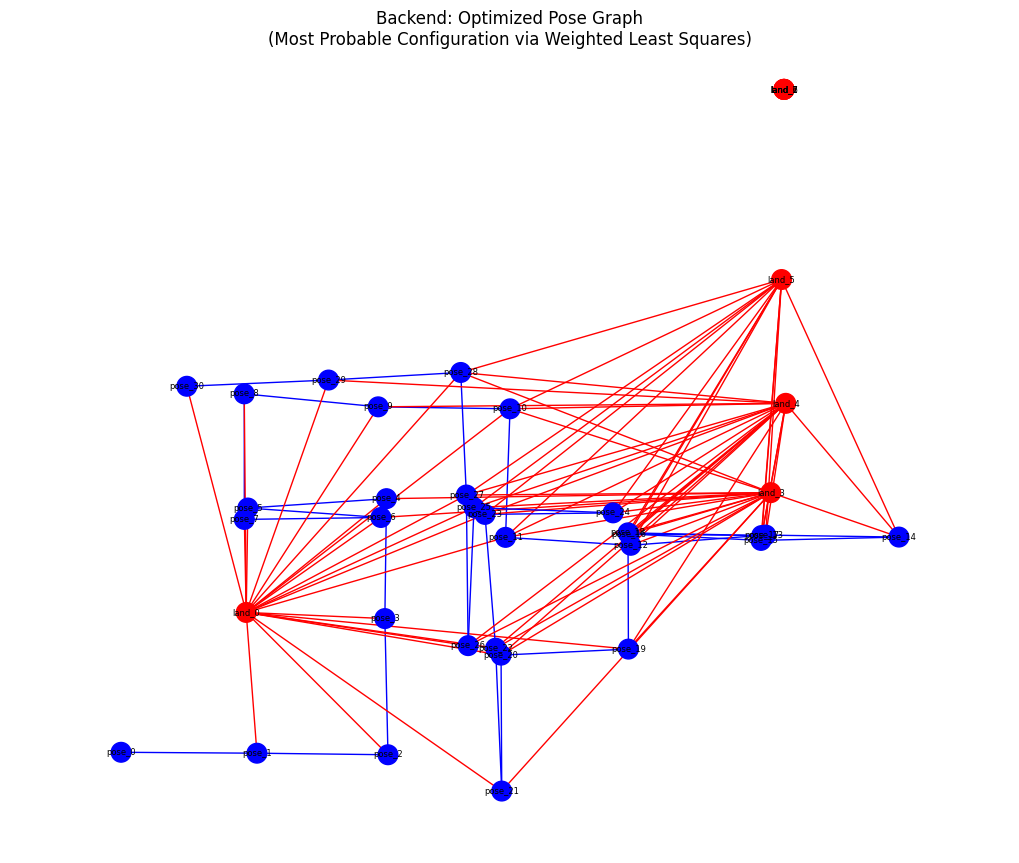

In [ ]:
# not Taylor
# 4. Backend: Find most probable pose (and map) configuration
# p(x_{1:T}, m | z_{1:T}, u_{1:T}, x_0) via Gaussian approximation
# Minimize negative log-likelihood: sum errors (Gaussian)
# Errors: odom (linear), obs (nonlinear: r, phi)
# Iterative local linearization via Levenberg-Marquardt (in least_squares)
# Information matrix: approx Hessian = J^T \Omega J, where \Omega = R^{-1} (weights 1/sigma^2 implicit in scaled residuals)
# Weights: path (odom) and obs weighted by 1/sigma; optimal via the minimization
# Fix pose_0 for gauge freedom

def residuals(x):
    """Stacked residuals: odom errors + obs errors, scaled by 1/sigma (info weights)"""
    res = []
    # Fixed pose 0
    px_prev, py_prev = 0, 0 # from 0.5
    # Odometry errors: linear constraints from transition model p(x_t | x_{t-1}, u_t)
    # real obs - expected observation
    for ti in range(1, T+1):
        idx = 2 * (ti - 1)
        px_t, py_t = x[idx:idx+2]
        u = odometry[ti-1]
        # Error: (x_t - x_{t-1} - u), weighted
        res.append(((px_t - px_prev) - u[0]) / sigma_odom)
        res.append(((py_t - py_prev) - u[1]) / sigma_odom)
        px_prev, py_prev = px_t, py_t

    # Observation errors: from p(z_t | x_t, m), nonlinear h(x_t, m) = (r, phi)
    offset = 2 * T
    for t in range(1, T+1):
        # Current pose (fixed for t=0, but t starts 1)
        idx_t = 2 * (t - 1)
        px_t, py_t = x[idx_t:idx_t+2]
        for j, z_r, z_phi in observations[t]: # related to landmarks
            idx_m = offset + 2 * j
            mx, my = x[idx_m:idx_m+2]
            dx = mx - px_t
            dy = my - py_t
            pred_r = np.sqrt(dx**2 + dy**2)
            pred_phi = np.arctan2(dy, dx)
            # Error: (z - pred), weighted; phi wrapped but small noise ok
            res.append((z_r - pred_r) / sigma_range)
            res.append((z_phi - pred_phi) / sigma_bearing)
    return np.array(res)


# Initial guess: stacked [poses_1 ... poses_T, landmarks]
var_size = 2 * T + 2 * K
x0 = np.zeros(var_size)
# Poses 1 to T
for ti in range(1, T+1):
    idx = 2 * (ti - 1)
    x0[idx:idx+2] = poses_est[ti] #u
# Landmarks
offset = 2 * T
for j in range(K):
    idx = offset + 2 * j
    x0[idx:idx+2] = landmarks_init[j]

# Optimize: minimizes sum ||residuals||^2 , iterative LM (local linearization)
print("Running backend optimization...")
sol = least_squares(residuals, x0, method='lm', verbose=1)
x_opt = sol.x
print(f"Optimization converged: cost = {sol.cost:.2f}")

# Extract optimized values
poses_opt1 = [np.array([0, 0])]  # Fixed pose 0
for ti in range(1, T+1):
    idx = 2 * (ti - 1)
    poses_opt1.append(x_opt[idx:idx+2])
landmarks_opt = []
offset = 2 * T
for j in range(K):
    idx = offset + 2 * j
    landmarks_opt.append(x_opt[idx:idx+2])

print("Optimized poses (first 5):", poses_opt1[:5])
print("Optimized landmarks:", landmarks_opt)

# Update graph with optimized positions (for visualization)
G_opt1 = G_init.copy()
for t in range(T+1):
    G_opt1.nodes[f'pose_{t}']['pos'] = poses_opt1[t]
for j in range(K):
    G_opt1.nodes[f'land_{j}']['pos'] = landmarks_opt[j]

# Visualize optimized graph
plt.figure(figsize=(10, 8))
pos_opt1 = nx.get_node_attributes(G_opt, 'pos')
nx.draw(G_opt1, pos_opt1, with_labels=True, node_color=node_colors, node_size=200,
        font_size=6, edge_color=['blue' if G_opt[u][v]['type']=='odom' else 'red' for u,v in G_opt.edges],
        width=1)
plt.title("Backend: Optimized Pose Graph\n(Most Probable Configuration via Weighted Least Squares)")
plt.axis('equal')
plt.show()


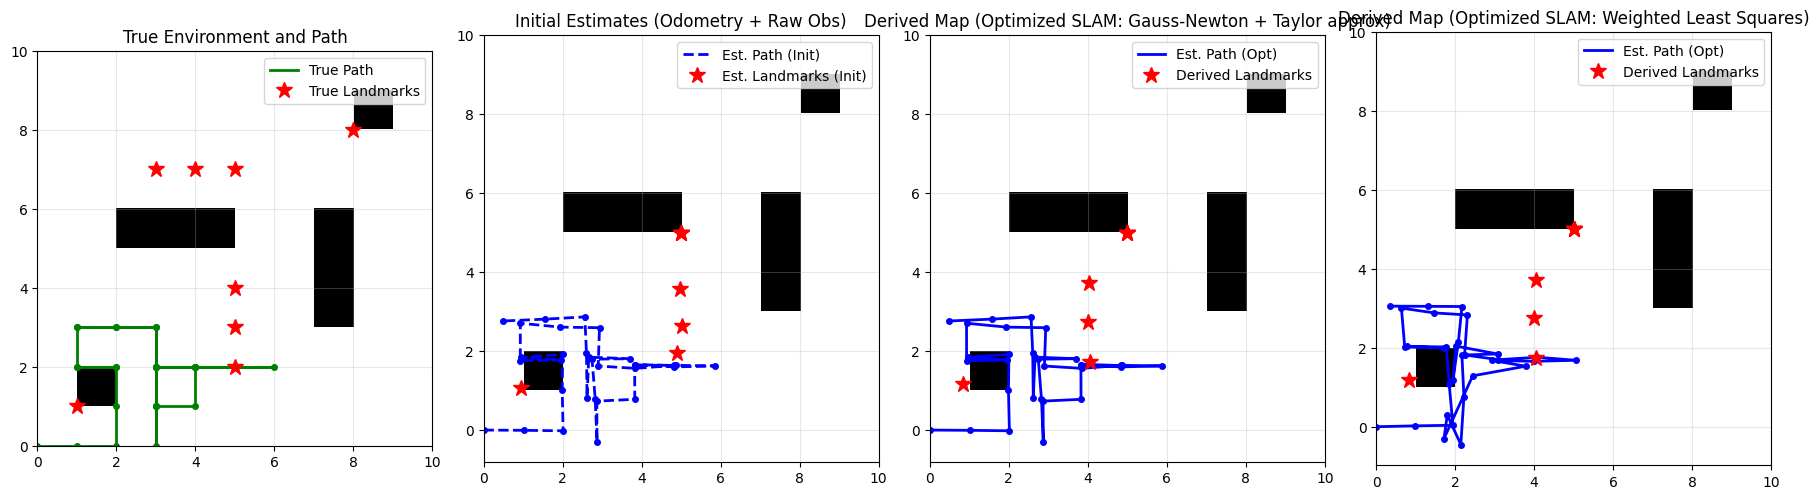

In [ ]:

# 5. Visualize derived map
# Plot: true env/path, initial est, optimized est (derived map from estimated landmarks/path)
env_array = np.array([[1 if c == '1' else 0 for c in row] for row in env])

fig, axs = plt.subplots(1, 4, figsize=(18, 5))

# True
axs[0].imshow(env_array, cmap='gray_r', origin='lower', extent=[0, N, 0, N])
axs[0].plot([p[0] for p in path_true], [p[1] for p in path_true], 'g-', linewidth=2, label='True Path')
axs[0].plot([p[0] for p in path_true], [p[1] for p in path_true], 'go', markersize=4)
for lm in landmarks_true:
    axs[0].plot(lm[0], lm[1], 'r*', markersize=12, label='True Landmarks' if np.array_equal(lm, landmarks_true[0]) else "")
axs[0].set_title('True Environment and Path')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Initial estimates (from frontend)
axs[1].imshow(env_array, cmap='gray_r', origin='lower', extent=[0, N, 0, N])
axs[1].plot([p[0] for p in poses_est], [p[1] for p in poses_est], 'b--', linewidth=2, label='Est. Path (Init)')
axs[1].plot([p[0] for p in poses_est], [p[1] for p in poses_est], 'bo', markersize=4)
for lm in landmarks_init:
    axs[1].plot(lm[0], lm[1], 'r*', markersize=12, label='Est. Landmarks (Init)' if np.array_equal(lm, landmarks_init[0]) else "")
axs[1].set_title('Initial Estimates (Odometry + Raw Obs)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# Derived map (optimized)
axs[2].imshow(env_array, cmap='gray_r', origin='lower', extent=[0, N, 0, N])
axs[2].plot([p[0] for p in poses_opt], [p[1] for p in poses_opt], 'b-', linewidth=2, label='Est. Path (Opt)')
axs[2].plot([p[0] for p in poses_opt], [p[1] for p in poses_opt], 'bo', markersize=4)
for lm in landmarks_opt:
    axs[2].plot(lm[0], lm[1], 'r*', markersize=12, label='Derived Landmarks' if np.array_equal(lm, landmarks_opt[0]) else "")
axs[2].set_title('Derived Map (Optimized SLAM: Gauss-Newton + Taylor approx)')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

# Derived map (optimized)
axs[3].imshow(env_array, cmap='gray_r', origin='lower', extent=[0, N, 0, N])
axs[3].plot([p[0] for p in poses_opt1], [p[1] for p in poses_opt1], 'b-', linewidth=2, label='Est. Path (Opt)')
axs[3].plot([p[0] for p in poses_opt1], [p[1] for p in poses_opt1], 'bo', markersize=4)
for lm in landmarks_opt:
    axs[3].plot(lm[0], lm[1], 'r*', markersize=12, label='Derived Landmarks' if np.array_equal(lm, landmarks_opt[0]) else "")
axs[3].set_title('Derived Map (Optimized SLAM: Weighted Least Squares)')
axs[3].legend()
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Notes on Dynamic Bayesian Network (integrated in models):
# P(x_t | e_{1:t}) \propto P(e_t | x_t) * \sum_{x_{t-1}} P(x_t | x_{t-1}, u_t) P(x_{t-1} | e_{1:t-1})
# Approximated via Gaussian factors in graph; joint p(x_{1:T}, m | z_{1:T}, u_{1:T}, x_0)
# Backend uses statistical test (chi2 via cost) for consistency.
# Information matrix emerges from \Omega = R^{-1} in edge costs: (z - h(x))^T \Omega (z - h(x))
# Weights adjusted via sigmas; optimal path found by minimizing total cost.


In [ ]:
def optimize(self):
    n_poses = len(self.poses) # ([x,y,theta])
    n_lm = len(self.landmarks)
    if n_poses == 0: return {'converged': False}
    x0 = np.concatenate([np.array(self.poses).flatten(),
                          np.array(self.landmarks).flatten() if n_lm>0 else []])
    fixed = self.poses[0].copy() # [x, y, theta]

    def cost_with_anchor(state_vec):
        state_vec[:3] = fixed
        return self.total_cost(state_vec)
    result = minimize(cost_with_anchor, x0, method='L-BFGS-B',
                      options={'maxiter':100,'ftol':1e-9})
    # cost: e omega e, where e = [x,y,theta] motion error: [x,y,theta]
    optimized = result.x
    opt_poses = optimized[:n_poses*3].reshape(n_poses,3) # [[x,y,theta],...]
    opt_lm = optimized[n_poses*3:].reshape(n_lm,2) if n_lm>0 else [] # [[x,y]]
    self.poses = [opt_poses[i] for i in range(n_poses)]
    self.landmarks = [opt_lm[i] for i in range(n_lm)]
    return {'trajectory':opt_poses, 'landmarks':opt_lm,
            'final_cost':result.fun, 'converged':result.success}


def update(self, result, x, y, theta, lidar_hits): # result_poses =
    self.clear()

    # 1. Draw the history of where the robot has been (Optional)
    if len(result['trajectory']) > 1:
        self.draw_trajectory(result['trajectory'].poses)

    # 2. Draw ONLY confirmed landmarks h
    if len(result['landmarks'].landmarks) > 0:
        self.draw_landmarks(result['landmarks'].landmarks)

    # if lidar_hits:
    #     self.draw_lidar(x, y, lidar_hits)

    # 4. Draw the robot on top
    self.draw_robot(x, y, theta)


Frontier: Graph

In [ ]:
print(poses_opt)
# map: landmark atp, create/update a tree for possible moves atp, dijkstra to new pos


Frontier Exploration [Array]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid constants
UNKNOWN = -1
FREE = 0
OCCUPIED = 1

# Create mock world (ground truth)
def create_world(size=50):
    world = np.zeros((size, size))

    # Add some obstacles
    world[10:15, 10:30] = OCCUPIED
    world[30:35, 5:20] = OCCUPIED
    world[20:40, 35:40] = OCCUPIED

    return world

# Initialize belief map
def init_map(size=50):
    return np.full((size, size), UNKNOWN)

def init_graph():
    nodes = []
    edges = []
    return nodes, edges

def reveal(map_belief, world, robot_pos, radius=5):
    x, y = robot_pos
    print(f"map shape: {map_belief.shape}")
    for i in range(map_belief.shape[0]):
        for j in range(map_belief.shape[1]):
            if (j - x)**2 + (i - y)**2 <= radius**2: # swap j, i
                map_belief[i, j] = world[i, j]
    return map_belief

def get_possible_paths():


# Simulate sensor (simple circular reveal)
def get_neighbors(x, y, W, H):
    directions = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    neighbors = []

    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < W and 0 <= ny < H:
            neighbors.append((nx, ny))

    return neighbors

def get_frontiers(map_belief):
    frontiers = []
    H, W = map_belief.shape

    for y in range(H):
        for x in range(W):
            if map_belief[y, x] == FREE:
                for nx, ny in get_neighbors(x, y, W, H):
                    if map_belief[ny, nx] == UNKNOWN:
                        frontiers.append((x, y))
                        break

    return frontiers

# get_frontiers(map_belief)
# select_best_frontier(frontiers, grid, robot_pos)
def compute_utility(frontier, grid, robot_pos):
    x, y = frontier
    H, W = grid.shape

    # Information gain = unknown neighbors around frontier
    info_gain = 0
    for nx, ny in get_neighbors(x, y, W, H):
        if grid[ny, nx] == UNKNOWN:
            info_gain += 1

    # Distance penalty
    dist = np.linalg.norm(np.array([x, y]) - np.array(robot_pos))

    alpha = 2.5   # increase this (important)
    beta = 1.0

    return alpha * info_gain - beta * dist

def select_best_frontier(frontiers, grid, robot_pos):
    best_score = -np.inf
    best_frontier = None

    for f in frontiers:
        score = compute_utility(f, grid, robot_pos)
        if score > best_score:
            best_score = score
            best_frontier = f

    return best_frontier

import heapq

def dijkstra(grid, start, goal):
    H, W = grid.shape
    pq = []
    heapq.heappush(pq, (0, start))

    dist = {start: 0}
    prev = {}

    while pq:
        cost, current = heapq.heappop(pq)

        if current == goal:
            break

        for nx, ny in get_neighbors(current[0], current[1], W, H):
            if grid[ny, nx] == OCCUPIED:  # obstacle
                continue

            new_cost = cost + 1

            if (nx, ny) not in dist or new_cost < dist[(nx, ny)]:
                dist[(nx, ny)] = new_cost
                prev[(nx, ny)] = current
                heapq.heappush(pq, (new_cost, (nx, ny)))

    return reconstruct_path(prev, start, goal)


def reconstruct_path(prev, start, goal):
    path = []
    cur = goal

    while cur != start:
        path.append(cur)
        cur = prev.get(cur)
        if cur is None:
            print("reconstruct_path: No path finding")
            return []  # no path

    path.append(start)
    path.reverse()
    return path


def exploration_step(grid, robot_pos):
    frontiers = get_frontiers(grid)

    if not frontiers:
        print("Exploration complete")
        return None

    target = select_best_frontier(frontiers, grid, robot_pos)
    # print(f"target: {target}")
    path = dijkstra(grid, robot_pos, target)
    print(f"dijkstra path: {path}")
    return path[1], path

# Visualization
def show(map_belief, robot, frontiers, path):
    vis = np.zeros_like(map_belief, dtype=float)

    # Map values to colors
    vis[map_belief == UNKNOWN] = 0.5   # gray
    vis[map_belief == FREE] = 1.0      # white
    vis[map_belief == OCCUPIED] = 0.0  # black

    # Mark frontiers
    for fx, fy in frontiers:
        vis[fy, fx] = 0.75  # light gray (frontier)

    plt.imshow(vis, cmap='gray', vmin=0, vmax=1)
    plt.scatter([p[0] for p in path], [p[1] for p in path], c='green')
    plt.scatter(robot[0], robot[1], c='red')
    plt.title("Frontier Exploration")
    plt.show()

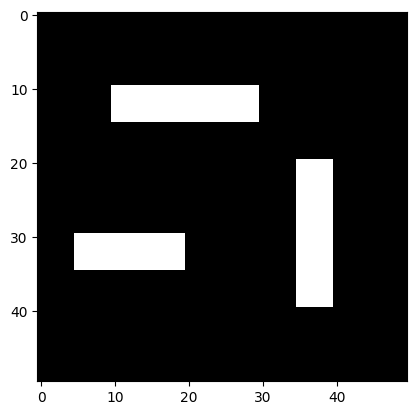

Step: 0
debugging position (10,15): -1
reveal map..
robot location: (25, 25)
map shape: (50, 50)
frontiers: [(25, 20), (22, 21), (23, 21), (24, 21), (25, 21), (26, 21), (27, 21), (28, 21), (21, 22), (22, 22), (28, 22), (29, 22), (21, 23), (29, 23), (21, 24), (29, 24), (20, 25), (21, 25), (29, 25), (30, 25), (21, 26), (29, 26), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(25, 25), (24, 24), (23, 23), (23, 22), (24, 21), (25, 20)]
target position: (24, 24)


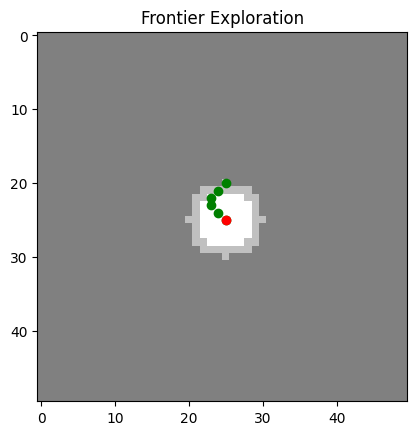

Step: 1
debugging position (10,15): -1
reveal map..
robot location: (24, 24)
map shape: (50, 50)
frontiers: [(24, 19), (21, 20), (22, 20), (23, 20), (24, 20), (25, 20), (26, 20), (27, 20), (20, 21), (21, 21), (27, 21), (28, 21), (20, 22), (28, 22), (29, 22), (20, 23), (29, 23), (19, 24), (20, 24), (29, 24), (20, 25), (29, 25), (30, 25), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(24, 24), (23, 23), (22, 22), (22, 21), (23, 20), (24, 19)]
target position: (23, 23)


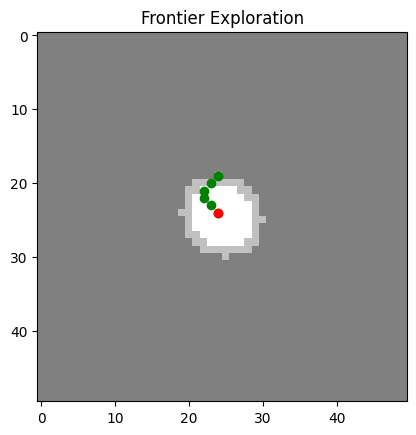

Step: 2
debugging position (10,15): -1
reveal map..
robot location: (23, 23)
map shape: (50, 50)
frontiers: [(23, 18), (20, 19), (21, 19), (22, 19), (23, 19), (24, 19), (25, 19), (26, 19), (19, 20), (20, 20), (26, 20), (27, 20), (19, 21), (27, 21), (28, 21), (19, 22), (28, 22), (29, 22), (18, 23), (19, 23), (29, 23), (19, 24), (29, 24), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(23, 23), (22, 22), (21, 21), (21, 20), (22, 19), (23, 18)]
target position: (22, 22)


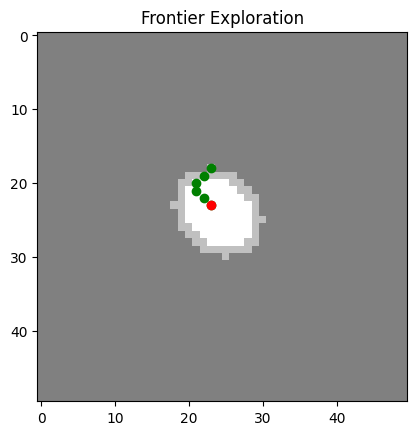

Step: 3
debugging position (10,15): -1
reveal map..
robot location: (22, 22)
map shape: (50, 50)
frontiers: [(22, 17), (19, 18), (20, 18), (21, 18), (22, 18), (23, 18), (24, 18), (25, 18), (18, 19), (19, 19), (25, 19), (26, 19), (18, 20), (26, 20), (27, 20), (18, 21), (27, 21), (28, 21), (17, 22), (18, 22), (28, 22), (29, 22), (18, 23), (29, 23), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(22, 22), (21, 21), (20, 20), (20, 19), (21, 18), (22, 17)]
target position: (21, 21)


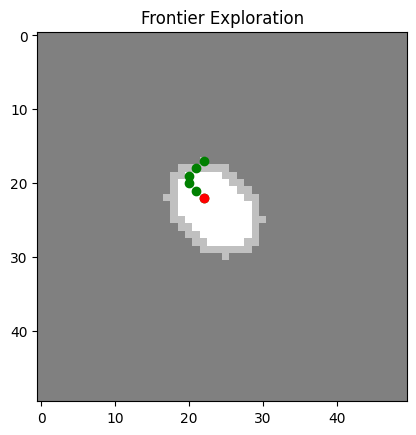

Step: 4
debugging position (10,15): -1
reveal map..
robot location: (21, 21)
map shape: (50, 50)
frontiers: [(21, 16), (18, 17), (19, 17), (20, 17), (21, 17), (22, 17), (23, 17), (24, 17), (17, 18), (18, 18), (24, 18), (25, 18), (17, 19), (25, 19), (26, 19), (17, 20), (26, 20), (27, 20), (16, 21), (17, 21), (27, 21), (28, 21), (17, 22), (28, 22), (29, 22), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(21, 21), (20, 20), (19, 19), (19, 18), (20, 17), (21, 16)]
target position: (20, 20)


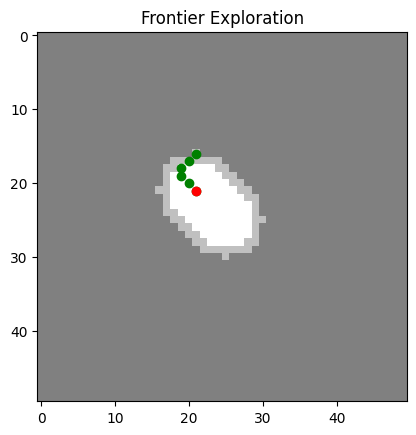

Step: 5
debugging position (10,15): -1
reveal map..
robot location: (20, 20)
map shape: (50, 50)
frontiers: [(20, 15), (17, 16), (18, 16), (19, 16), (20, 16), (21, 16), (22, 16), (23, 16), (16, 17), (17, 17), (23, 17), (24, 17), (16, 18), (24, 18), (25, 18), (16, 19), (25, 19), (26, 19), (15, 20), (16, 20), (26, 20), (27, 20), (16, 21), (27, 21), (28, 21), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(20, 20), (19, 19), (18, 18), (18, 17), (19, 16), (20, 15)]
target position: (19, 19)


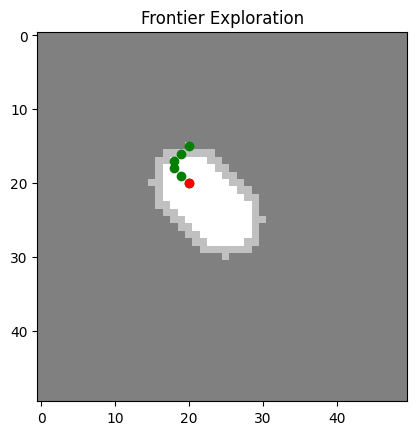

Step: 6
debugging position (10,15): -1
reveal map..
robot location: (19, 19)
map shape: (50, 50)
frontiers: [(16, 15), (17, 15), (18, 15), (19, 15), (20, 15), (21, 15), (22, 15), (15, 16), (16, 16), (22, 16), (23, 16), (15, 17), (23, 17), (24, 17), (15, 18), (24, 18), (25, 18), (14, 19), (15, 19), (25, 19), (26, 19), (15, 20), (26, 20), (27, 20), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(19, 19), (18, 18), (17, 17), (16, 17), (15, 18), (14, 19)]
target position: (18, 18)


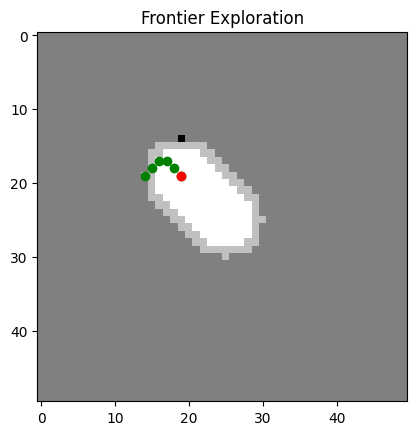

Step: 7
debugging position (10,15): -1
reveal map..
robot location: (18, 18)
map shape: (50, 50)
frontiers: [(14, 15), (15, 15), (21, 15), (22, 15), (14, 16), (22, 16), (23, 16), (14, 17), (23, 17), (24, 17), (13, 18), (14, 18), (24, 18), (25, 18), (14, 19), (25, 19), (26, 19), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(18, 18), (17, 17), (16, 16), (15, 16), (14, 17), (13, 18)]
target position: (17, 17)


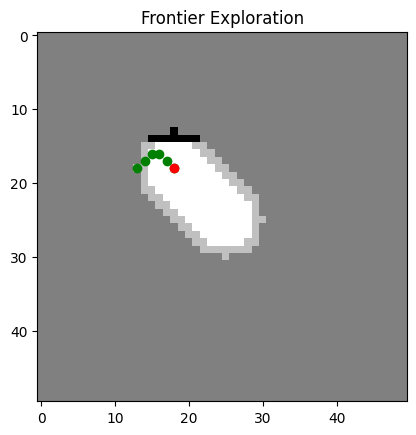

Step: 8
debugging position (10,15): -1
reveal map..
robot location: (17, 17)
map shape: (50, 50)
frontiers: [(13, 15), (21, 15), (22, 15), (13, 16), (22, 16), (23, 16), (12, 17), (13, 17), (23, 17), (24, 17), (13, 18), (24, 18), (25, 18), (13, 19), (25, 19), (26, 19), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(17, 17), (16, 16), (15, 15), (14, 15), (13, 16), (12, 17)]
target position: (16, 16)


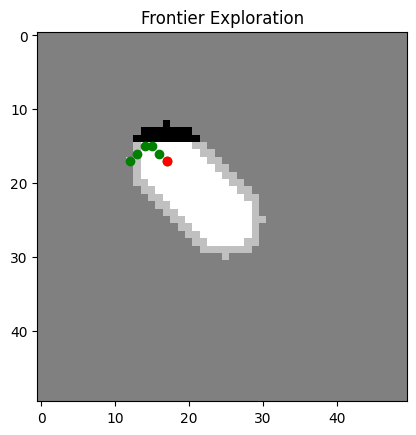

Step: 9
debugging position (10,15): -1
reveal map..
robot location: (16, 16)
map shape: (50, 50)
frontiers: [(12, 15), (21, 15), (22, 15), (11, 16), (12, 16), (22, 16), (23, 16), (12, 17), (23, 17), (24, 17), (12, 18), (24, 18), (25, 18), (12, 19), (13, 19), (25, 19), (26, 19), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(16, 16), (15, 15), (14, 15), (13, 15), (12, 15), (11, 16)]
target position: (15, 15)


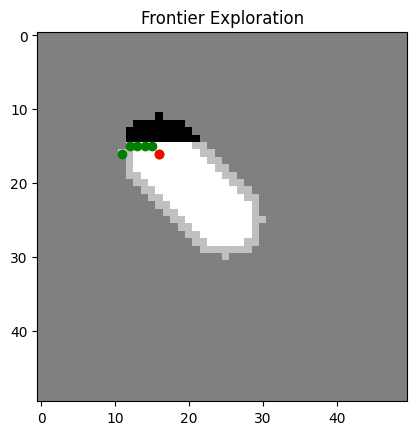

Step: 10
debugging position (10,15): -1
reveal map..
robot location: (15, 15)
map shape: (50, 50)
frontiers: [(10, 15), (11, 15), (21, 15), (22, 15), (11, 16), (22, 16), (23, 16), (11, 17), (23, 17), (24, 17), (11, 18), (12, 18), (24, 18), (25, 18), (12, 19), (13, 19), (25, 19), (26, 19), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(15, 15), (14, 15), (13, 15), (12, 15), (11, 15), (10, 15)]
target position: (14, 15)


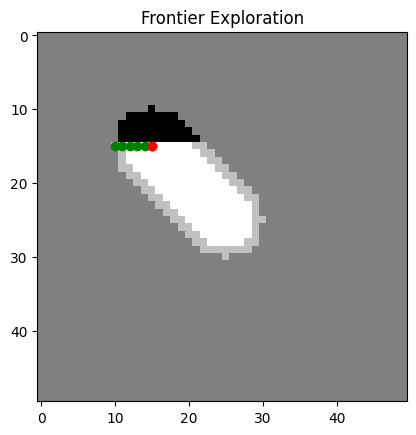

Step: 11
debugging position (10,15): 1
reveal map..
robot location: (14, 15)
map shape: (50, 50)
frontiers: [(9, 15), (10, 15), (21, 15), (22, 15), (10, 16), (22, 16), (23, 16), (10, 17), (23, 17), (24, 17), (10, 18), (11, 18), (24, 18), (25, 18), (11, 19), (12, 19), (13, 19), (25, 19), (26, 19), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(14, 15), (13, 15), (12, 15), (11, 15), (10, 15), (9, 15)]
target position: (13, 15)


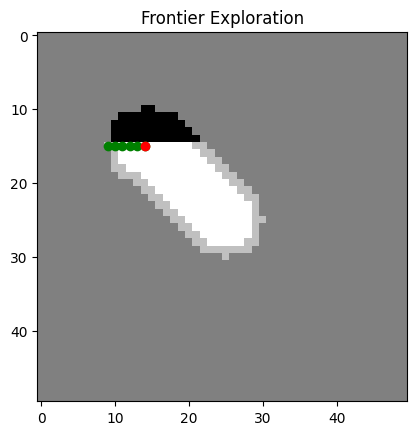

Step: 12
debugging position (10,15): 1
reveal map..
robot location: (13, 15)
map shape: (50, 50)
frontiers: [(9, 12), (9, 13), (9, 14), (8, 15), (9, 15), (21, 15), (22, 15), (9, 16), (22, 16), (23, 16), (9, 17), (23, 17), (24, 17), (9, 18), (10, 18), (24, 18), (25, 18), (10, 19), (11, 19), (12, 19), (13, 19), (25, 19), (26, 19), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(13, 15), (12, 15), (11, 15), (10, 15), (9, 14), (8, 15)]
target position: (12, 15)


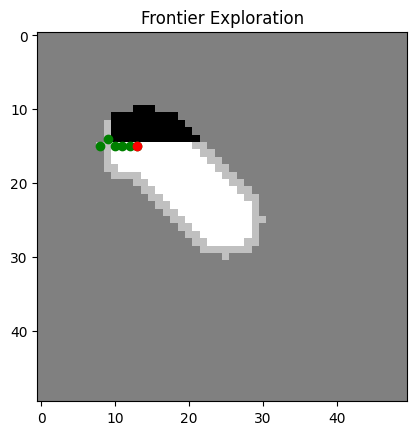

Step: 13
debugging position (10,15): 1
reveal map..
robot location: (12, 15)
map shape: (50, 50)
frontiers: [(9, 11), (8, 12), (9, 12), (8, 13), (8, 14), (7, 15), (8, 15), (21, 15), (22, 15), (8, 16), (22, 16), (23, 16), (8, 17), (23, 17), (24, 17), (8, 18), (9, 18), (24, 18), (25, 18), (9, 19), (10, 19), (11, 19), (12, 19), (25, 19), (26, 19), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(12, 15), (11, 15), (10, 15), (9, 14), (8, 14), (7, 15)]
target position: (11, 15)


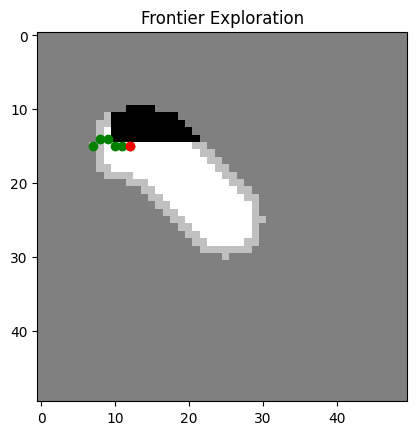

Step: 14
debugging position (10,15): 1
reveal map..
robot location: (11, 15)
map shape: (50, 50)
frontiers: [(8, 11), (9, 11), (7, 12), (8, 12), (7, 13), (7, 14), (6, 15), (7, 15), (21, 15), (22, 15), (7, 16), (22, 16), (23, 16), (7, 17), (23, 17), (24, 17), (7, 18), (8, 18), (24, 18), (25, 18), (8, 19), (9, 19), (10, 19), (11, 19), (25, 19), (26, 19), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(11, 15), (10, 15), (9, 14), (8, 13), (7, 14), (6, 15)]
target position: (10, 15)


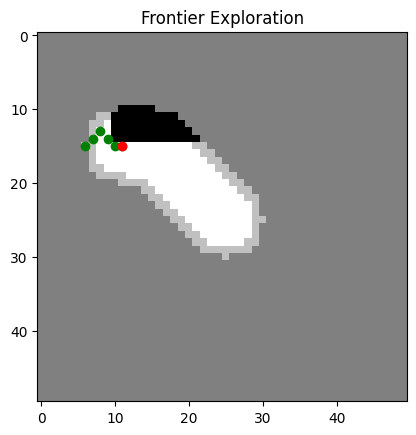

Step: 15
debugging position (10,15): 1
reveal map..
robot location: (10, 15)
map shape: (50, 50)
frontiers: [(7, 11), (8, 11), (9, 11), (6, 12), (7, 12), (6, 13), (6, 14), (5, 15), (6, 15), (21, 15), (22, 15), (6, 16), (22, 16), (23, 16), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(10, 15), (9, 14), (8, 13), (7, 13), (6, 14), (5, 15)]
target position: (9, 14)


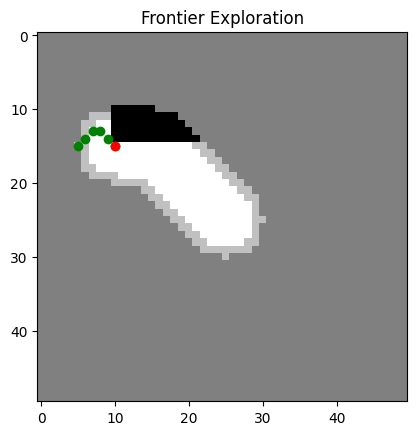

Step: 16
debugging position (10,15): 1
reveal map..
robot location: (9, 14)
map shape: (50, 50)
frontiers: [(9, 9), (6, 10), (7, 10), (8, 10), (9, 10), (5, 11), (6, 11), (5, 12), (5, 13), (4, 14), (5, 14), (5, 15), (21, 15), (22, 15), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(9, 14), (8, 13), (7, 12), (7, 11), (8, 10), (9, 9)]
target position: (8, 13)


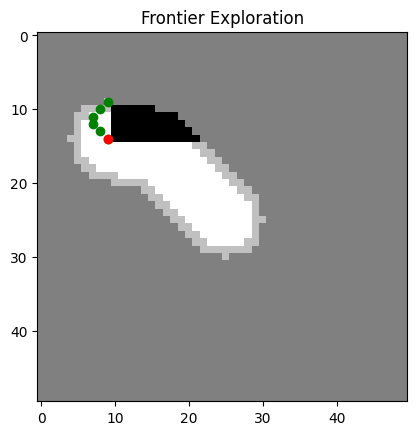

Step: 17
debugging position (10,15): 1
reveal map..
robot location: (8, 13)
map shape: (50, 50)
frontiers: [(8, 8), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9), (10, 9), (11, 9), (4, 10), (5, 10), (4, 11), (4, 12), (3, 13), (4, 13), (4, 14), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(8, 13), (7, 12), (6, 11), (6, 10), (7, 9), (8, 8)]
target position: (7, 12)


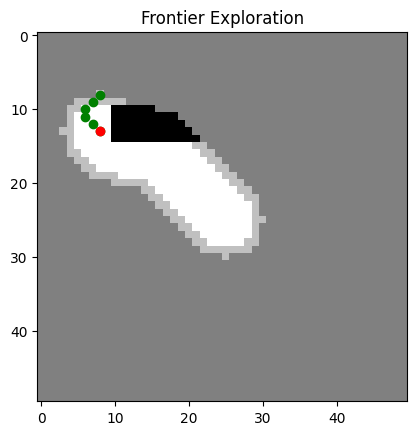

Step: 18
debugging position (10,15): 1
reveal map..
robot location: (7, 12)
map shape: (50, 50)
frontiers: [(7, 7), (4, 8), (5, 8), (6, 8), (7, 8), (8, 8), (9, 8), (10, 8), (3, 9), (4, 9), (10, 9), (11, 9), (3, 10), (3, 11), (2, 12), (3, 12), (3, 13), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(7, 12), (6, 11), (5, 10), (5, 9), (6, 8), (7, 7)]
target position: (6, 11)


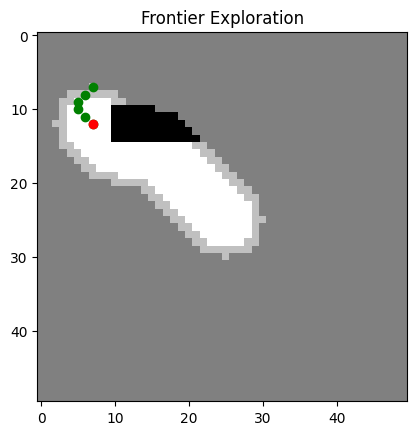

Step: 19
debugging position (10,15): 1
reveal map..
robot location: (6, 11)
map shape: (50, 50)
frontiers: [(6, 6), (3, 7), (4, 7), (5, 7), (6, 7), (7, 7), (8, 7), (9, 7), (2, 8), (3, 8), (9, 8), (10, 8), (2, 9), (10, 9), (11, 9), (2, 10), (1, 11), (2, 11), (2, 12), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(6, 11), (5, 10), (4, 9), (4, 8), (5, 7), (6, 6)]
t

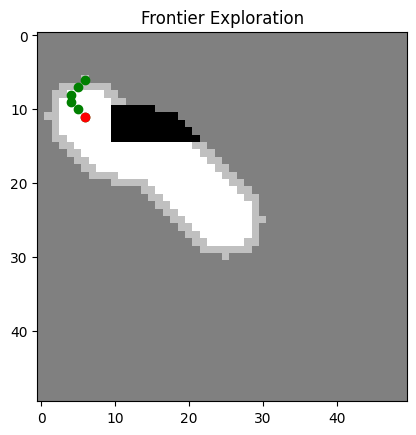

Step: 20
debugging position (10,15): 1
reveal map..
robot location: (5, 10)
map shape: (50, 50)
frontiers: [(5, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 6), (1, 7), (2, 7), (8, 7), (9, 7), (1, 8), (9, 8), (10, 8), (1, 9), (10, 9), (11, 9), (0, 10), (1, 10), (1, 11), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(5, 10), (4, 9), (

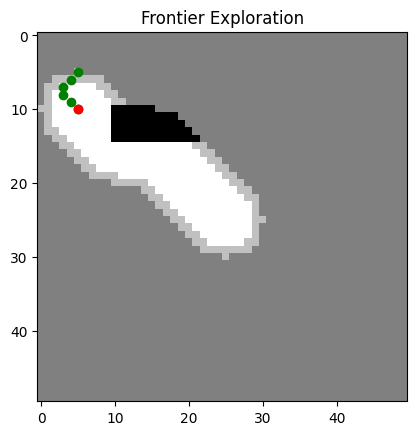

Step: 21
debugging position (10,15): 1
reveal map..
robot location: (4, 9)
map shape: (50, 50)
frontiers: [(4, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (6, 5), (7, 5), (0, 6), (1, 6), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(4, 9), (3, 8), (2, 7), (2, 6), (3, 5

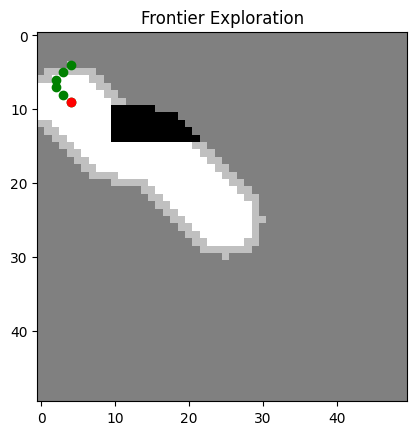

Step: 22
debugging position (10,15): 1
reveal map..
robot location: (3, 8)
map shape: (50, 50)
frontiers: [(3, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4), (5, 4), (6, 4), (6, 5), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(3, 8), (2, 7), (1, 6), (1, 5), (2, 4

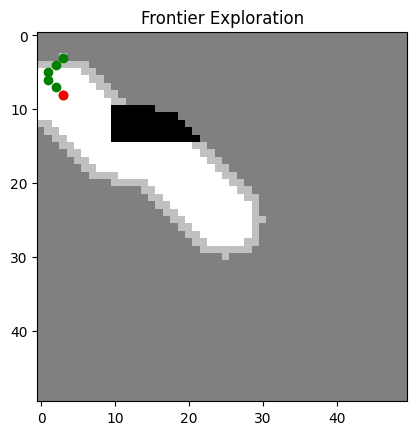

Step: 23
debugging position (10,15): 1
reveal map..
robot location: (2, 7)
map shape: (50, 50)
frontiers: [(2, 2), (0, 3), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (5, 4), (6, 4), (6, 5), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(2, 7), (1, 6), (0, 5), (0, 4

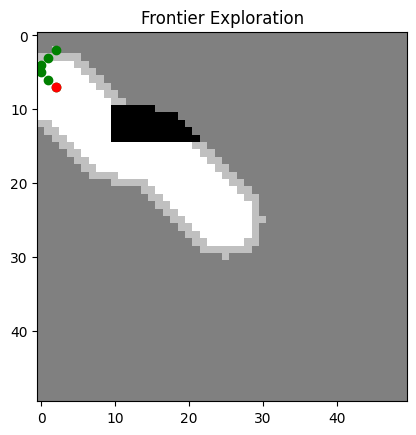

Step: 24
debugging position (10,15): 1
reveal map..
robot location: (1, 6)
map shape: (50, 50)
frontiers: [(1, 1), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (4, 3), (5, 3), (5, 4), (6, 4), (6, 5), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(1, 6), (0, 5), (0, 4

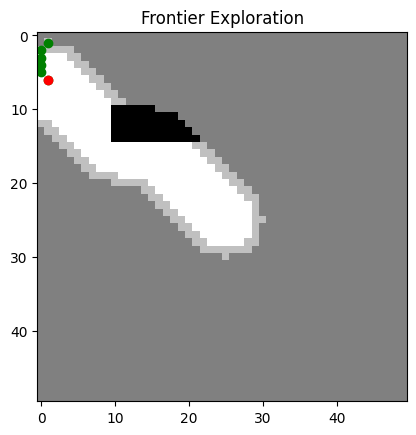

Step: 25
debugging position (10,15): 1
reveal map..
robot location: (0, 5)
map shape: (50, 50)
frontiers: [(0, 0), (0, 1), (1, 1), (2, 1), (3, 1), (3, 2), (4, 2), (4, 3), (5, 3), (5, 4), (6, 4), (6, 5), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(0, 5), (0, 4

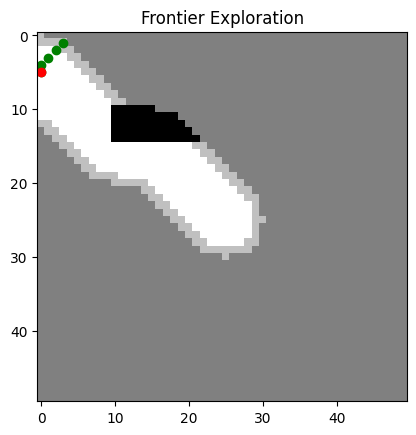

Step: 26
debugging position (10,15): 1
reveal map..
robot location: (0, 4)
map shape: (50, 50)
frontiers: [(3, 0), (3, 1), (4, 1), (4, 2), (4, 3), (5, 3), (5, 4), (6, 4), (6, 5), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(0, 4), (1, 3), (2, 2), (3, 1), (4, 1

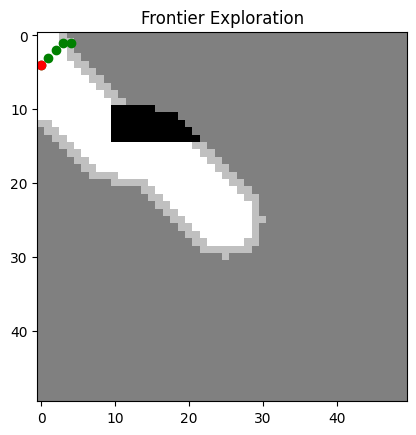

Step: 27
debugging position (10,15): 1
reveal map..
robot location: (1, 3)
map shape: (50, 50)
frontiers: [(5, 0), (5, 1), (5, 2), (5, 3), (6, 3), (6, 4), (6, 5), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(1, 3), (2, 2), (3, 1), (4, 1), (5, 2), (6, 3)]
targe

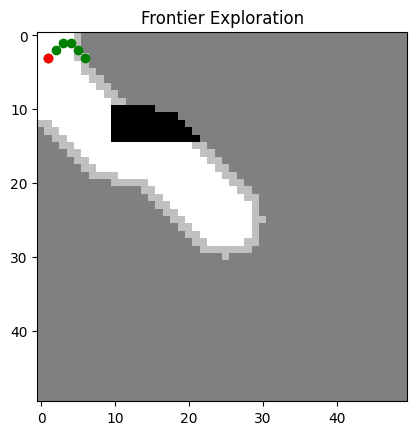

Step: 28
debugging position (10,15): 1
reveal map..
robot location: (2, 2)
map shape: (50, 50)
frontiers: [(6, 0), (6, 1), (6, 2), (7, 2), (6, 3), (6, 4), (6, 5), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(2, 2), (3, 1), (4, 0), (5, 0), (6, 1), (7, 2)]
targe

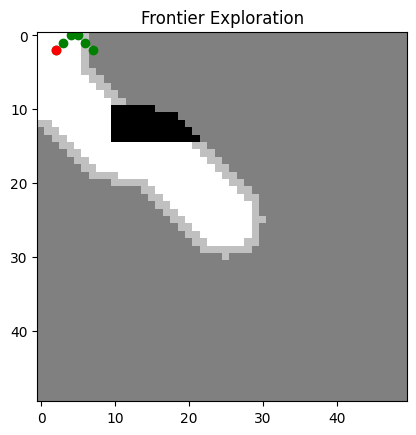

Step: 29
debugging position (10,15): 1
reveal map..
robot location: (3, 1)
map shape: (50, 50)
frontiers: [(7, 0), (7, 1), (8, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(3, 1), (4, 0), (5, 0), (6, 0), (7, 0), (8, 1)]
target positi

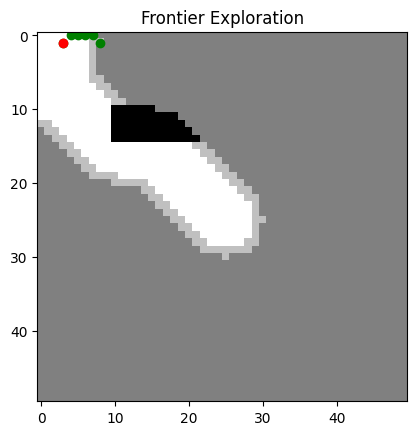

Step: 30
debugging position (10,15): 1
reveal map..
robot location: (4, 0)
map shape: (50, 50)
frontiers: [(8, 0), (9, 0), (8, 1), (8, 2), (7, 3), (8, 3), (7, 4), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(4, 0), (5, 0), (6, 1), (7, 2), (8, 3)]
target positi

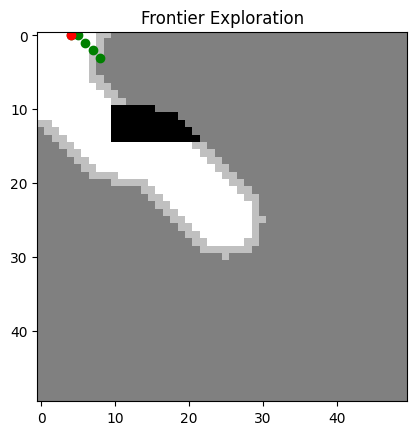

Step: 31
debugging position (10,15): 1
reveal map..
robot location: (5, 0)
map shape: (50, 50)
frontiers: [(9, 0), (10, 0), (9, 1), (9, 2), (8, 3), (9, 3), (7, 4), (8, 4), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(5, 0), (6, 0), (7, 1), (8, 2), (9, 3)]
targ

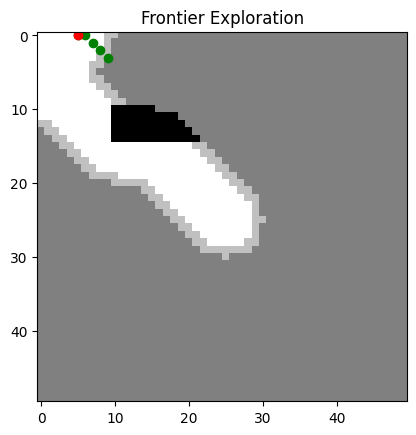

Step: 32
debugging position (10,15): 1
reveal map..
robot location: (6, 0)
map shape: (50, 50)
frontiers: [(10, 0), (11, 0), (10, 1), (10, 2), (9, 3), (10, 3), (7, 4), (8, 4), (9, 4), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(6, 0), (7, 0), (8, 1), (9, 2), 

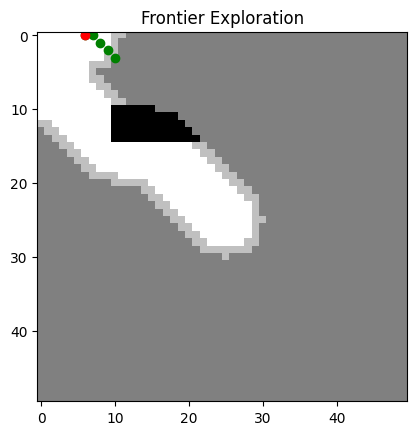

Step: 33
debugging position (10,15): 1
reveal map..
robot location: (7, 0)
map shape: (50, 50)
frontiers: [(11, 0), (12, 0), (11, 1), (11, 2), (10, 3), (11, 3), (7, 4), (8, 4), (9, 4), (10, 4), (7, 5), (7, 6), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(7, 0), (8, 0), (9, 1)

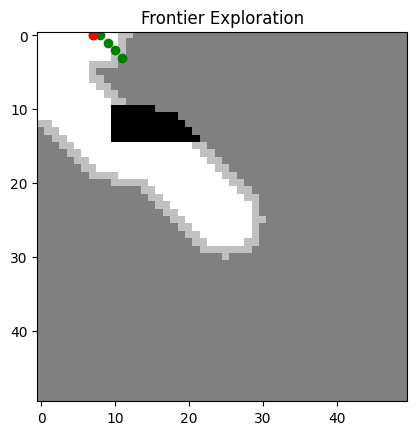

Step: 34
debugging position (10,15): 1
reveal map..
robot location: (8, 0)
map shape: (50, 50)
frontiers: [(12, 0), (13, 0), (12, 1), (12, 2), (11, 3), (12, 3), (8, 4), (9, 4), (10, 4), (11, 4), (8, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(8, 0), (9, 0), (10, 1), (11,

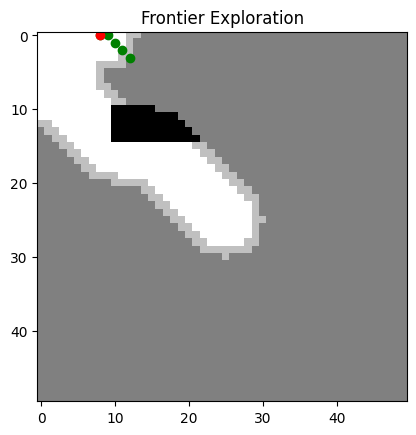

Step: 35
debugging position (10,15): 1
reveal map..
robot location: (9, 0)
map shape: (50, 50)
frontiers: [(13, 0), (14, 0), (13, 1), (13, 2), (12, 3), (13, 3), (9, 4), (10, 4), (11, 4), (12, 4), (8, 5), (9, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(9, 0), (10, 0), (11

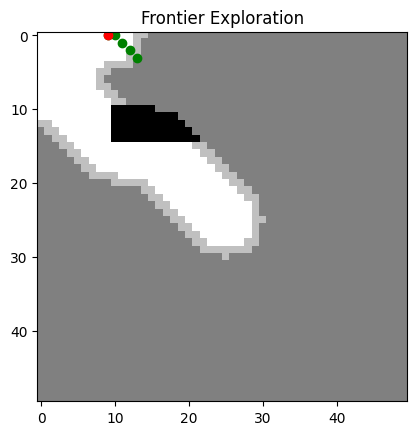

Step: 36
debugging position (10,15): 1
reveal map..
robot location: (10, 0)
map shape: (50, 50)
frontiers: [(14, 0), (15, 0), (14, 1), (14, 2), (13, 3), (14, 3), (10, 4), (11, 4), (12, 4), (13, 4), (8, 5), (9, 5), (10, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [(10, 0), 

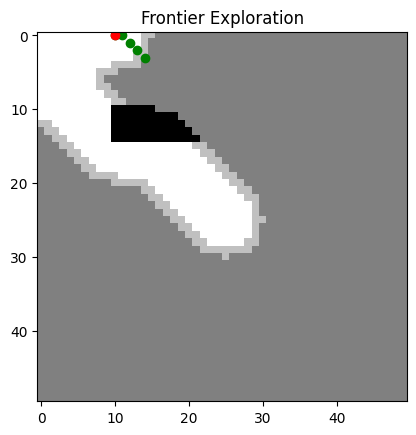

Step: 37
debugging position (10,15): 1
reveal map..
robot location: (11, 0)
map shape: (50, 50)
frontiers: [(15, 0), (16, 0), (15, 1), (15, 2), (14, 3), (15, 3), (11, 4), (12, 4), (13, 4), (14, 4), (8, 5), (9, 5), (10, 5), (11, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstra path: [

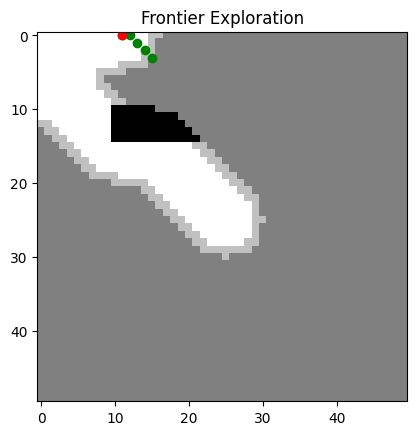

Step: 38
debugging position (10,15): 1
reveal map..
robot location: (12, 0)
map shape: (50, 50)
frontiers: [(16, 0), (17, 0), (16, 1), (16, 2), (15, 3), (16, 3), (12, 4), (13, 4), (14, 4), (15, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)]
dijkstr

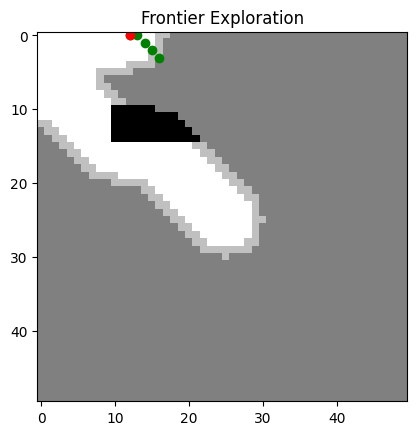

Step: 39
debugging position (10,15): 1
reveal map..
robot location: (13, 0)
map shape: (50, 50)
frontiers: [(17, 0), (18, 0), (17, 1), (17, 2), (16, 3), (17, 3), (13, 4), (14, 4), (15, 4), (16, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29), (25, 30)

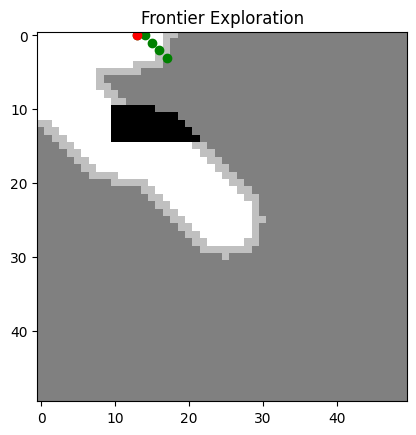

Step: 40
debugging position (10,15): 1
reveal map..
robot location: (14, 0)
map shape: (50, 50)
frontiers: [(18, 0), (19, 0), (18, 1), (18, 2), (17, 3), (18, 3), (14, 4), (15, 4), (16, 4), (17, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), (28, 29),

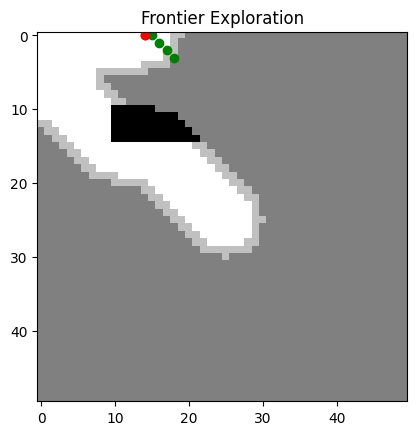

Step: 41
debugging position (10,15): 1
reveal map..
robot location: (15, 0)
map shape: (50, 50)
frontiers: [(19, 0), (20, 0), (19, 1), (19, 2), (18, 3), (19, 3), (15, 4), (16, 4), (17, 4), (18, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (27, 29), 

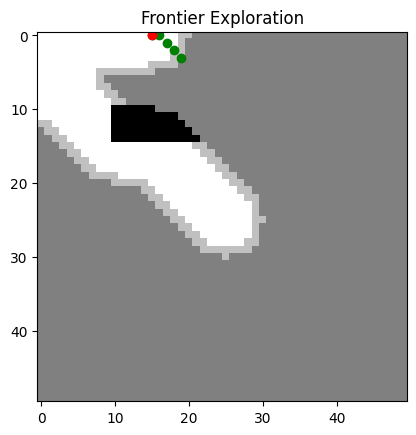

Step: 42
debugging position (10,15): 1
reveal map..
robot location: (16, 0)
map shape: (50, 50)
frontiers: [(20, 0), (21, 0), (20, 1), (20, 2), (19, 3), (20, 3), (16, 4), (17, 4), (18, 4), (19, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (26, 29), (

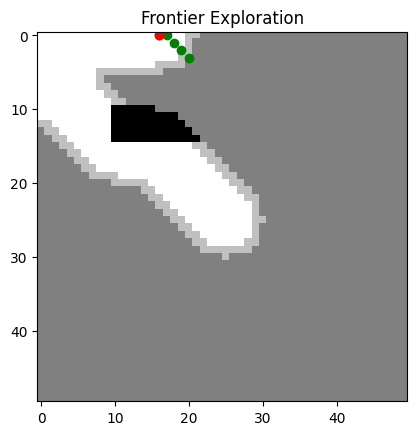

Step: 43
debugging position (10,15): 1
reveal map..
robot location: (17, 0)
map shape: (50, 50)
frontiers: [(21, 0), (22, 0), (21, 1), (21, 2), (20, 3), (21, 3), (17, 4), (18, 4), (19, 4), (20, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25, 29), (2

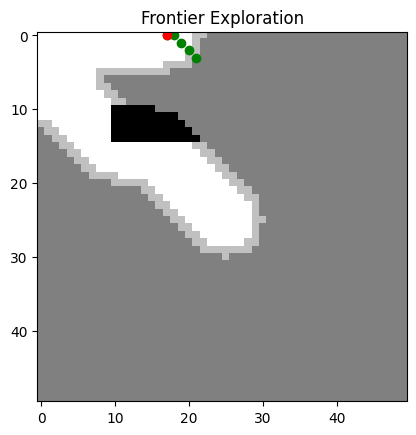

Step: 44
debugging position (10,15): 1
reveal map..
robot location: (18, 0)
map shape: (50, 50)
frontiers: [(22, 0), (23, 0), (22, 1), (22, 2), (21, 3), (22, 3), (18, 4), (19, 4), (20, 4), (21, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24, 29), (25

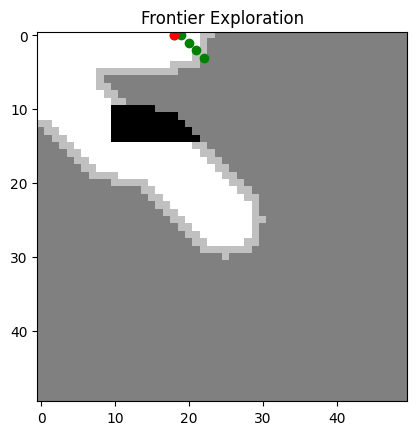

Step: 45
debugging position (10,15): 1
reveal map..
robot location: (19, 0)
map shape: (50, 50)
frontiers: [(23, 0), (24, 0), (23, 1), (23, 2), (22, 3), (23, 3), (19, 4), (20, 4), (21, 4), (22, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 29), (24,

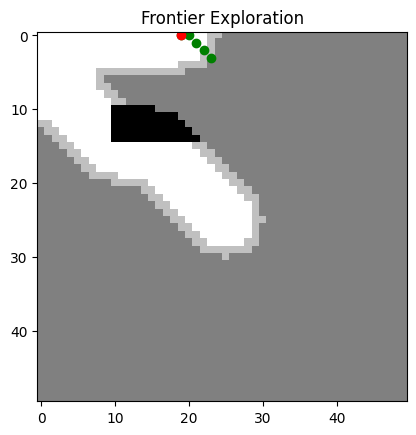

Step: 46
debugging position (10,15): 1
reveal map..
robot location: (20, 0)
map shape: (50, 50)
frontiers: [(24, 0), (25, 0), (24, 1), (24, 2), (23, 3), (24, 3), (20, 4), (21, 4), (22, 4), (23, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 29), (23, 

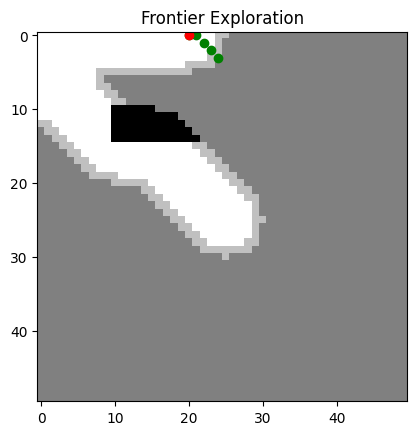

Step: 47
debugging position (10,15): 1
reveal map..
robot location: (21, 0)
map shape: (50, 50)
frontiers: [(25, 0), (26, 0), (25, 1), (25, 2), (24, 3), (25, 3), (21, 4), (22, 4), (23, 4), (24, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28), (22, 2

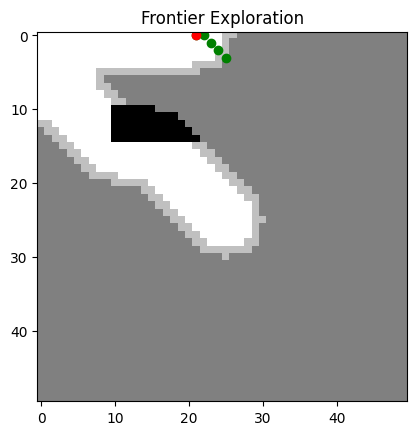

Step: 48
debugging position (10,15): 1
reveal map..
robot location: (22, 0)
map shape: (50, 50)
frontiers: [(26, 0), (27, 0), (26, 1), (26, 2), (25, 3), (26, 3), (22, 4), (23, 4), (24, 4), (25, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28), (29, 28

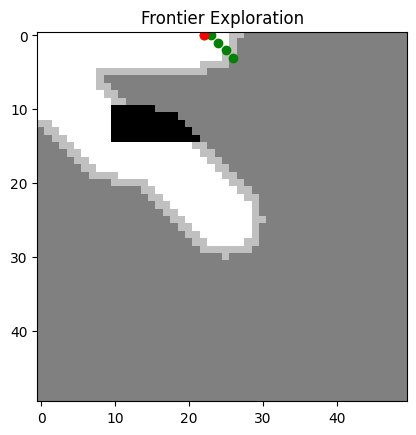

Step: 49
debugging position (10,15): 1
reveal map..
robot location: (23, 0)
map shape: (50, 50)
frontiers: [(27, 0), (28, 0), (27, 1), (27, 2), (26, 3), (27, 3), (23, 4), (24, 4), (25, 4), (26, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28), (28, 28)

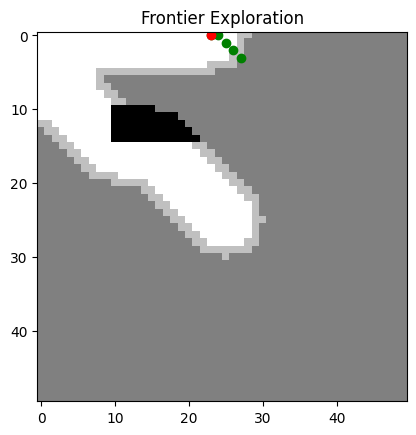

Step: 50
debugging position (10,15): 1
reveal map..
robot location: (24, 0)
map shape: (50, 50)
frontiers: [(28, 0), (29, 0), (28, 1), (28, 2), (27, 3), (28, 3), (24, 4), (25, 4), (26, 4), (27, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), (22, 28),

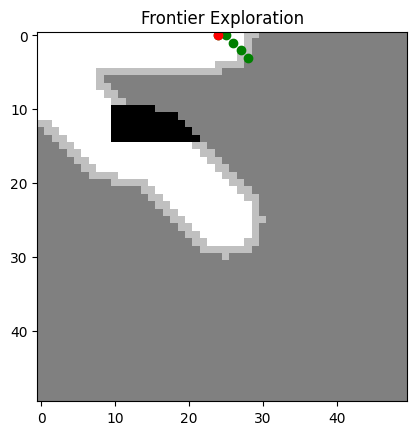

Step: 51
debugging position (10,15): 1
reveal map..
robot location: (25, 0)
map shape: (50, 50)
frontiers: [(29, 0), (30, 0), (29, 1), (29, 2), (28, 3), (29, 3), (25, 4), (26, 4), (27, 4), (28, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (21, 28), 

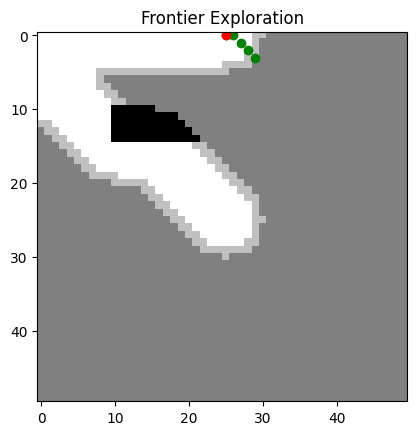

Step: 52
debugging position (10,15): 1
reveal map..
robot location: (26, 0)
map shape: (50, 50)
frontiers: [(30, 0), (31, 0), (30, 1), (30, 2), (29, 3), (30, 3), (26, 4), (27, 4), (28, 4), (29, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (29, 27), (

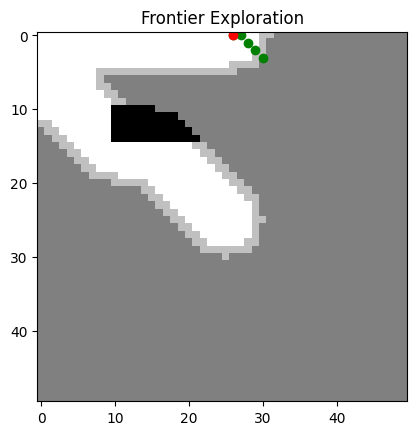

Step: 53
debugging position (10,15): 1
reveal map..
robot location: (27, 0)
map shape: (50, 50)
frontiers: [(31, 0), (32, 0), (31, 1), (31, 2), (30, 3), (31, 3), (27, 4), (28, 4), (29, 4), (30, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21, 27), (2

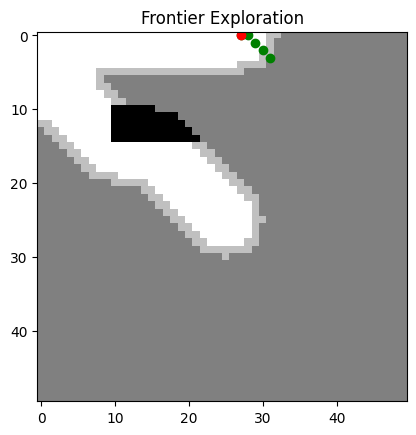

Step: 54
debugging position (10,15): 1
reveal map..
robot location: (28, 0)
map shape: (50, 50)
frontiers: [(32, 0), (33, 0), (32, 1), (32, 2), (31, 3), (32, 3), (28, 4), (29, 4), (30, 4), (31, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20, 27), (21

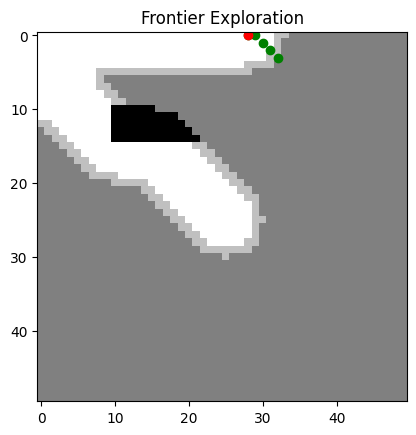

Step: 55
debugging position (10,15): 1
reveal map..
robot location: (29, 0)
map shape: (50, 50)
frontiers: [(33, 0), (34, 0), (33, 1), (33, 2), (32, 3), (33, 3), (29, 4), (30, 4), (31, 4), (32, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 26), (20,

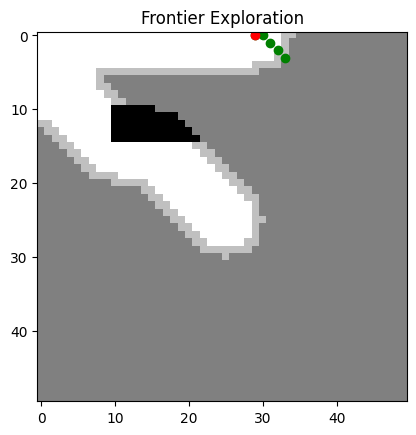

Step: 56
debugging position (10,15): 1
reveal map..
robot location: (30, 0)
map shape: (50, 50)
frontiers: [(34, 0), (35, 0), (34, 1), (34, 2), (33, 3), (34, 3), (30, 4), (31, 4), (32, 4), (33, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 26), (29, 

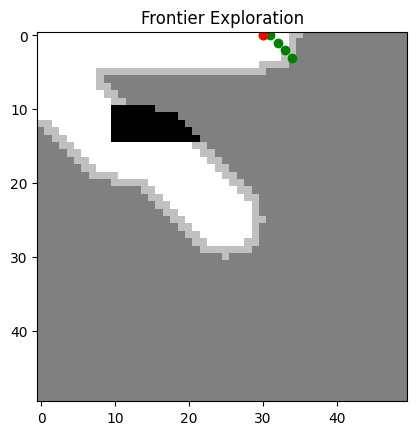

Step: 57
debugging position (10,15): 1
reveal map..
robot location: (31, 0)
map shape: (50, 50)
frontiers: [(35, 0), (36, 0), (35, 1), (35, 2), (34, 3), (35, 3), (31, 4), (32, 4), (33, 4), (34, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26), (20, 2

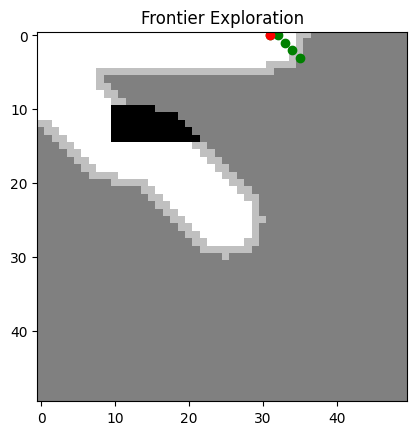

Step: 58
debugging position (10,15): 1
reveal map..
robot location: (32, 0)
map shape: (50, 50)
frontiers: [(36, 0), (37, 0), (36, 1), (36, 2), (35, 3), (36, 3), (32, 4), (33, 4), (34, 4), (35, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25), (19, 26

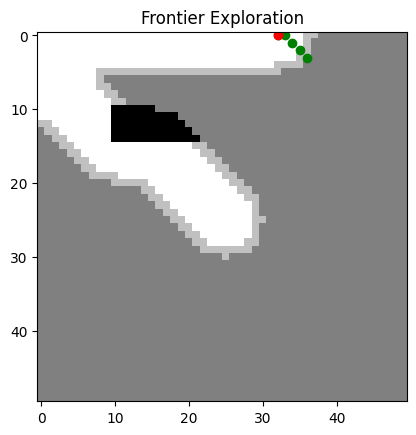

Step: 59
debugging position (10,15): 1
reveal map..
robot location: (33, 0)
map shape: (50, 50)
frontiers: [(37, 0), (38, 0), (37, 1), (37, 2), (36, 3), (37, 3), (33, 4), (34, 4), (35, 4), (36, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25), (30, 25)

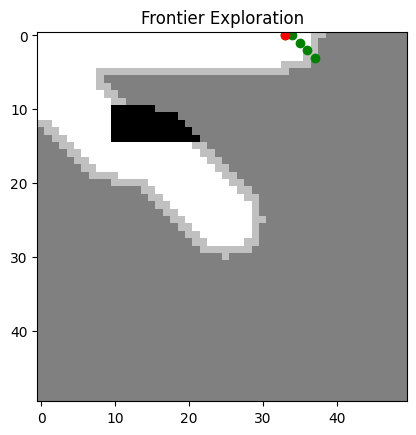

Step: 60
debugging position (10,15): 1
reveal map..
robot location: (34, 0)
map shape: (50, 50)
frontiers: [(38, 0), (39, 0), (38, 1), (38, 2), (37, 3), (38, 3), (34, 4), (35, 4), (36, 4), (37, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), (29, 25),

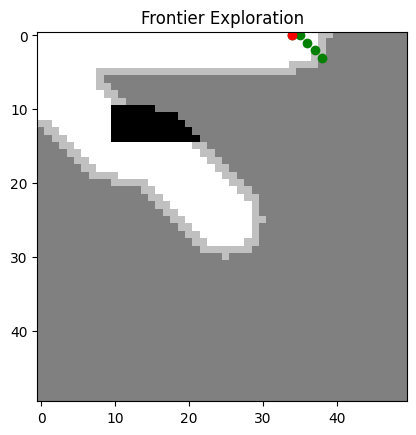

Step: 61
debugging position (10,15): 1
reveal map..
robot location: (35, 0)
map shape: (50, 50)
frontiers: [(39, 0), (40, 0), (39, 1), (39, 2), (38, 3), (39, 3), (35, 4), (36, 4), (37, 4), (38, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (19, 25), 

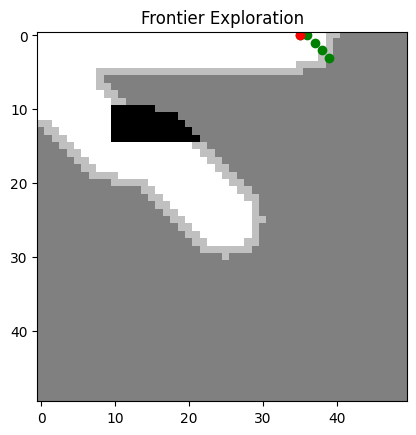

Step: 62
debugging position (10,15): 1
reveal map..
robot location: (36, 0)
map shape: (50, 50)
frontiers: [(40, 0), (41, 0), (40, 1), (40, 2), (39, 3), (40, 3), (36, 4), (37, 4), (38, 4), (39, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (18, 25), (

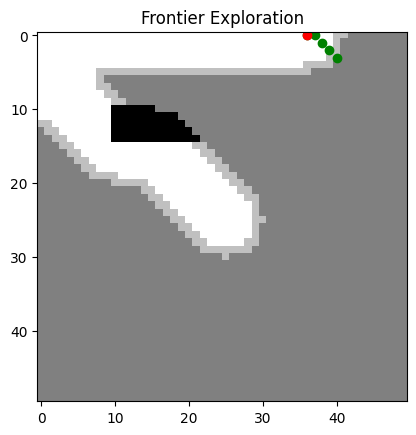

Step: 63
debugging position (10,15): 1
reveal map..
robot location: (37, 0)
map shape: (50, 50)
frontiers: [(41, 0), (42, 0), (41, 1), (41, 2), (40, 3), (41, 3), (37, 4), (38, 4), (39, 4), (40, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29, 24), (1

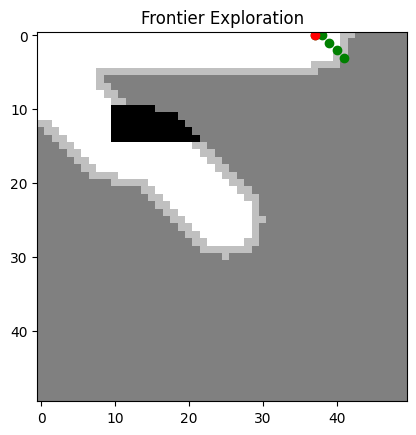

Step: 64
debugging position (10,15): 1
reveal map..
robot location: (38, 0)
map shape: (50, 50)
frontiers: [(42, 0), (43, 0), (42, 1), (42, 2), (41, 3), (42, 3), (38, 4), (39, 4), (40, 4), (41, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18, 24), (29

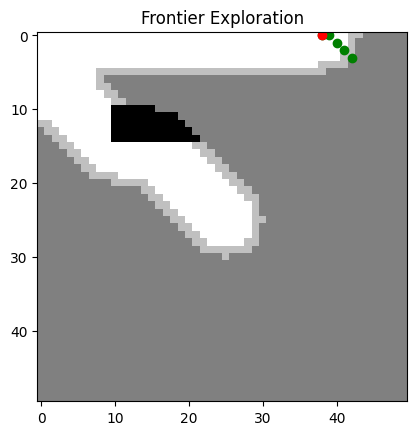

Step: 65
debugging position (10,15): 1
reveal map..
robot location: (39, 0)
map shape: (50, 50)
frontiers: [(43, 0), (44, 0), (43, 1), (43, 2), (42, 3), (43, 3), (39, 4), (40, 4), (41, 4), (42, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 24), (18,

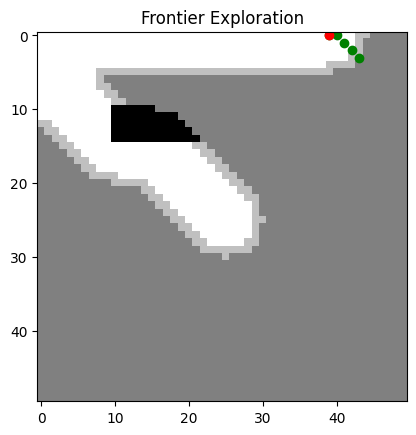

Step: 66
debugging position (10,15): 1
reveal map..
robot location: (40, 0)
map shape: (50, 50)
frontiers: [(44, 0), (45, 0), (44, 1), (44, 2), (43, 3), (44, 3), (40, 4), (41, 4), (42, 4), (43, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 23), (17, 

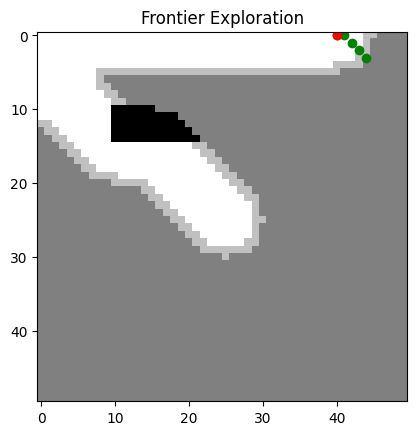

Step: 67
debugging position (10,15): 1
reveal map..
robot location: (41, 0)
map shape: (50, 50)
frontiers: [(45, 0), (46, 0), (45, 1), (45, 2), (44, 3), (45, 3), (41, 4), (42, 4), (43, 4), (44, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 2

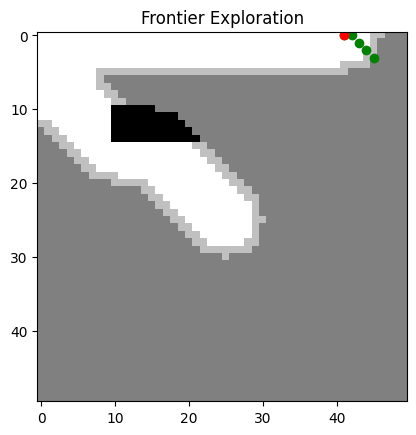

Step: 68
debugging position (10,15): 1
reveal map..
robot location: (42, 0)
map shape: (50, 50)
frontiers: [(46, 0), (47, 0), (46, 1), (46, 2), (45, 3), (46, 3), (42, 4), (43, 4), (44, 4), (45, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (42, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23

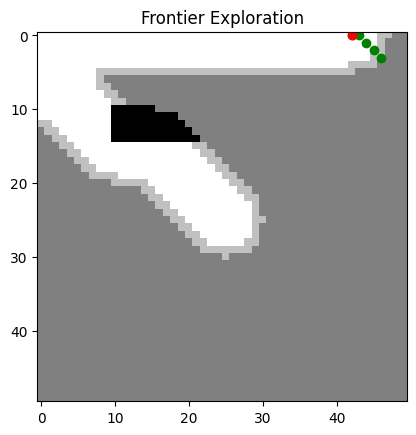

Step: 69
debugging position (10,15): 1
reveal map..
robot location: (43, 0)
map shape: (50, 50)
frontiers: [(47, 0), (48, 0), (47, 1), (47, 2), (46, 3), (47, 3), (43, 4), (44, 4), (45, 4), (46, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (42, 5), (43, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23)

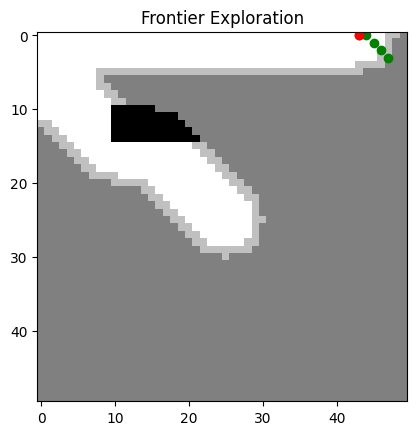

Step: 70
debugging position (10,15): 1
reveal map..
robot location: (44, 0)
map shape: (50, 50)
frontiers: [(48, 0), (49, 0), (48, 1), (48, 2), (47, 3), (48, 3), (44, 4), (45, 4), (46, 4), (47, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (42, 5), (43, 5), (44, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22),

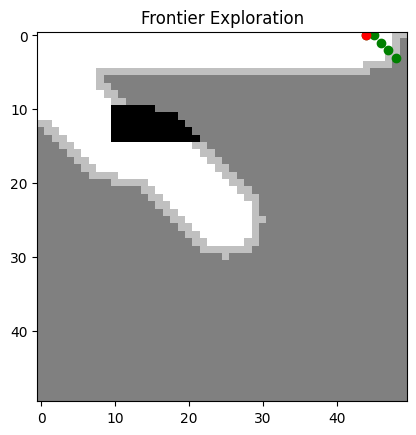

Step: 71
debugging position (10,15): 1
reveal map..
robot location: (45, 0)
map shape: (50, 50)
frontiers: [(48, 3), (49, 3), (45, 4), (46, 4), (47, 4), (48, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (42, 5), (43, 5), (44, 5), (45, 5), (8, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 2

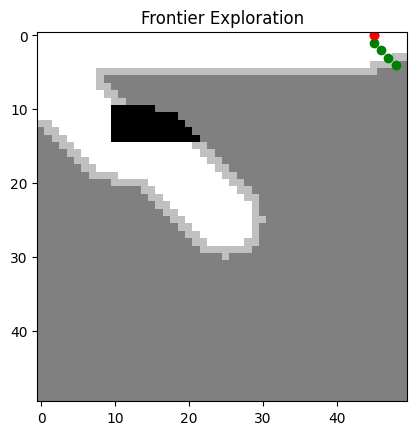

Step: 72
debugging position (10,15): 1
reveal map..
robot location: (45, 1)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (42, 5), (43, 5), (44, 5), (45, 5), (46, 5), (47, 5), (48, 5), (8, 6), (45, 6), (8, 7), (9, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23), (17, 23), (29, 2

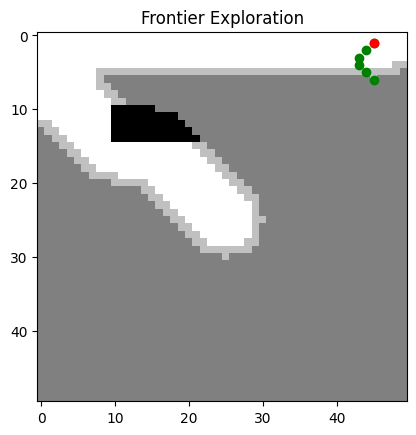

Step: 73
debugging position (10,15): 1
reveal map..
robot location: (44, 2)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (40, 5), (41, 5), (47, 5), (48, 5), (8, 6), (41, 6), (42, 6), (43, 6), (44, 6), (45, 6), (46, 6), (47, 6), (8, 7), (9, 7), (44, 7), (9, 8), (10, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), (29, 22), (16, 23)

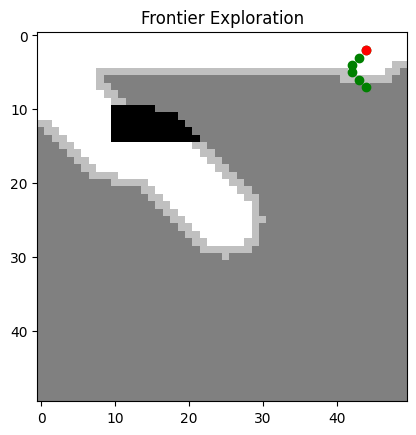

Step: 74
debugging position (10,15): 1
reveal map..
robot location: (43, 3)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (39, 5), (47, 5), (48, 5), (8, 6), (39, 6), (40, 6), (46, 6), (47, 6), (8, 7), (9, 7), (40, 7), (41, 7), (42, 7), (43, 7), (44, 7), (45, 7), (46, 7), (9, 8), (10, 8), (43, 8), (10, 9), (11, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22), 

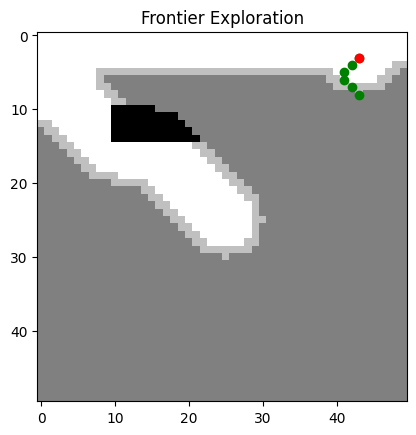

Step: 75
debugging position (10,15): 1
reveal map..
robot location: (42, 4)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (38, 5), (47, 5), (48, 5), (8, 6), (38, 6), (46, 6), (47, 6), (8, 7), (9, 7), (38, 7), (39, 7), (45, 7), (46, 7), (9, 8), (10, 8), (39, 8), (40, 8), (41, 8), (42, 8), (43, 8), (44, 8), (45, 8), (10, 9), (11, 9), (42, 9), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (1

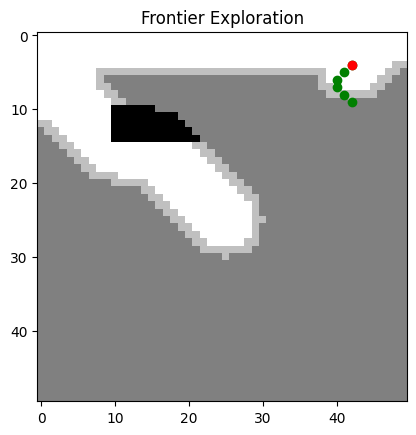

Step: 76
debugging position (10,15): 1
reveal map..
robot location: (41, 5)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (36, 5), (37, 5), (47, 5), (48, 5), (8, 6), (37, 6), (46, 6), (47, 6), (8, 7), (9, 7), (37, 7), (45, 7), (46, 7), (9, 8), (10, 8), (37, 8), (38, 8), (44, 8), (45, 8), (10, 9), (11, 9), (38, 9), (39, 9), (40, 9), (41, 9), (42, 9), (43, 9), (44, 9), (41, 10), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28

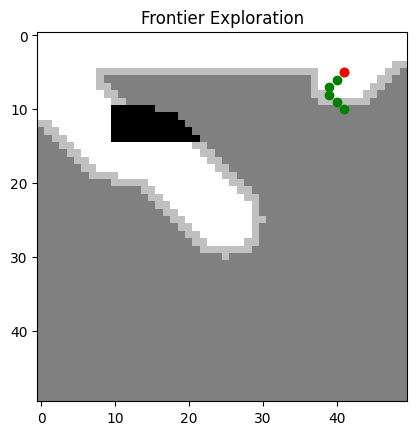

Step: 77
debugging position (10,15): 1
reveal map..
robot location: (40, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (47, 5), (48, 5), (8, 6), (35, 6), (36, 6), (46, 6), (47, 6), (8, 7), (9, 7), (36, 7), (45, 7), (46, 7), (9, 8), (10, 8), (36, 8), (44, 8), (45, 8), (10, 9), (11, 9), (36, 9), (37, 9), (43, 9), (44, 9), (37, 10), (38, 10), (39, 10), (40, 10), (41, 10), (42, 10), (43, 10), (40, 11), (0, 12), (1, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21)

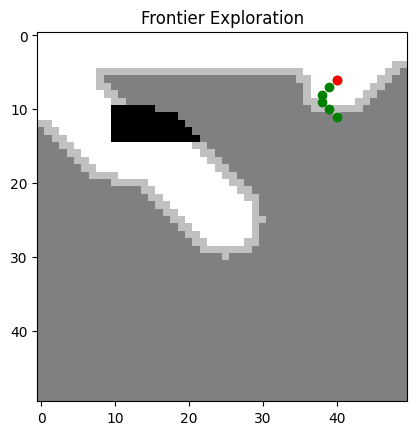

Step: 78
debugging position (10,15): 1
reveal map..
robot location: (39, 7)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (34, 5), (35, 5), (47, 5), (48, 5), (8, 6), (35, 6), (46, 6), (47, 6), (8, 7), (9, 7), (34, 7), (35, 7), (45, 7), (46, 7), (9, 8), (10, 8), (35, 8), (44, 8), (45, 8), (10, 9), (11, 9), (35, 9), (43, 9), (44, 9), (35, 10), (36, 10), (42, 10), (43, 10), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20

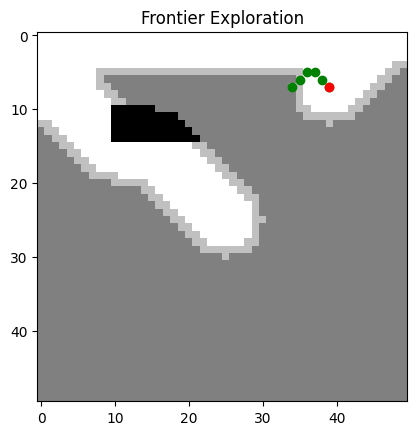

Step: 79
debugging position (10,15): 1
reveal map..
robot location: (38, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (47, 5), (48, 5), (8, 6), (33, 6), (34, 6), (46, 6), (47, 6), (8, 7), (9, 7), (34, 7), (45, 7), (46, 7), (9, 8), (10, 8), (34, 8), (44, 8), (45, 8), (10, 9), (11, 9), (34, 9), (35, 9), (43, 9), (44, 9), (35, 10), (36, 10), (42, 10), (43, 10), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 2

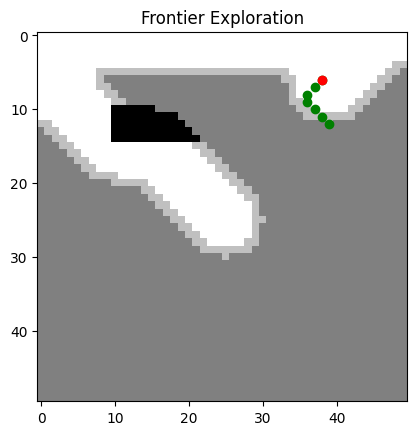

Step: 80
debugging position (10,15): 1
reveal map..
robot location: (37, 7)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (32, 5), (33, 5), (47, 5), (48, 5), (8, 6), (33, 6), (46, 6), (47, 6), (8, 7), (9, 7), (32, 7), (33, 7), (45, 7), (46, 7), (9, 8), (10, 8), (33, 8), (44, 8), (45, 8), (10, 9), (11, 9), (33, 9), (43, 9), (44, 9), (33, 10), (34, 10), (42, 10), (43, 10), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 

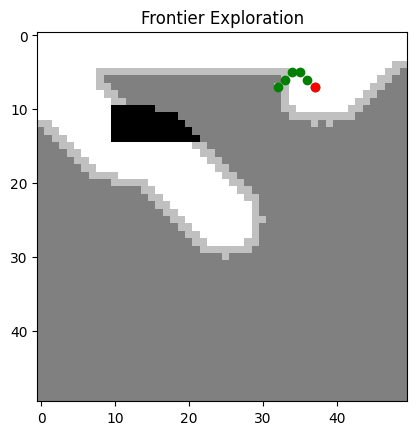

Step: 81
debugging position (10,15): 1
reveal map..
robot location: (36, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (47, 5), (48, 5), (8, 6), (31, 6), (32, 6), (46, 6), (47, 6), (8, 7), (9, 7), (32, 7), (45, 7), (46, 7), (9, 8), (10, 8), (32, 8), (44, 8), (45, 8), (10, 9), (11, 9), (32, 9), (33, 9), (43, 9), (44, 9), (33, 10), (34, 10), (42, 10), (43, 10), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14,

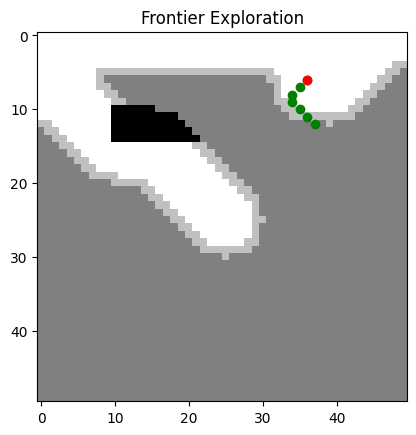

Step: 82
debugging position (10,15): 1
reveal map..
robot location: (35, 7)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (30, 5), (31, 5), (47, 5), (48, 5), (8, 6), (31, 6), (46, 6), (47, 6), (8, 7), (9, 7), (30, 7), (31, 7), (45, 7), (46, 7), (9, 8), (10, 8), (31, 8), (44, 8), (45, 8), (10, 9), (11, 9), (31, 9), (43, 9), (44, 9), (31, 10), (32, 10), (42, 10), (43, 10), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12

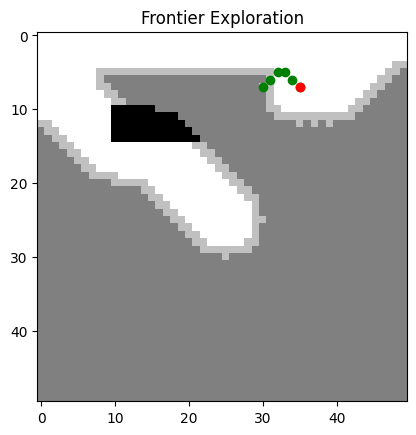

Step: 83
debugging position (10,15): 1
reveal map..
robot location: (34, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (47, 5), (48, 5), (8, 6), (29, 6), (30, 6), (46, 6), (47, 6), (8, 7), (9, 7), (30, 7), (45, 7), (46, 7), (9, 8), (10, 8), (30, 8), (44, 8), (45, 8), (10, 9), (11, 9), (30, 9), (31, 9), (43, 9), (44, 9), (31, 10), (32, 10), (42, 10), (43, 10), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (1

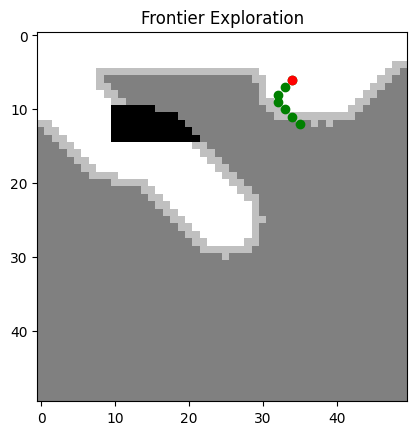

Step: 84
debugging position (10,15): 1
reveal map..
robot location: (33, 7)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (28, 5), (29, 5), (47, 5), (48, 5), (8, 6), (29, 6), (46, 6), (47, 6), (8, 7), (9, 7), (28, 7), (29, 7), (45, 7), (46, 7), (9, 8), (10, 8), (29, 8), (44, 8), (45, 8), (10, 9), (11, 9), (29, 9), (43, 9), (44, 9), (30, 10), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (

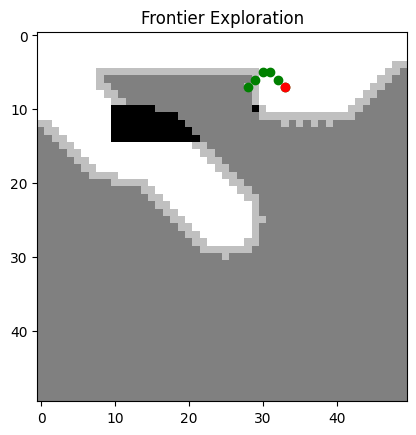

Step: 85
debugging position (10,15): 1
reveal map..
robot location: (32, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (47, 5), (48, 5), (8, 6), (27, 6), (28, 6), (46, 6), (47, 6), (8, 7), (9, 7), (28, 7), (45, 7), (46, 7), (9, 8), (10, 8), (28, 8), (44, 8), (45, 8), (10, 9), (11, 9), (28, 9), (29, 9), (43, 9), (44, 9), (30, 10), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), 

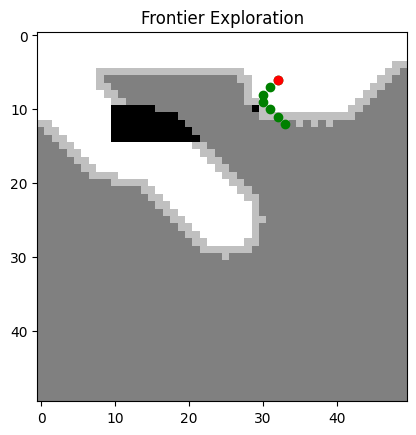

Step: 86
debugging position (10,15): 1
reveal map..
robot location: (31, 7)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (26, 5), (27, 5), (47, 5), (48, 5), (8, 6), (27, 6), (46, 6), (47, 6), (8, 7), (9, 7), (26, 7), (27, 7), (45, 7), (46, 7), (9, 8), (10, 8), (27, 8), (44, 8), (45, 8), (10, 9), (11, 9), (27, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20),

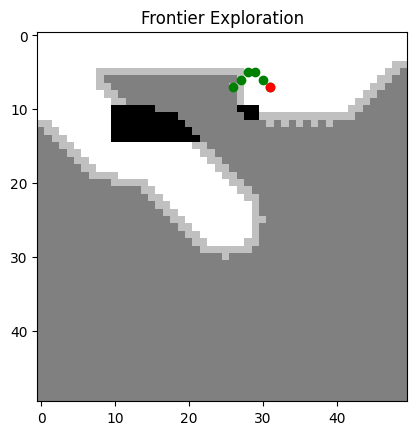

Step: 87
debugging position (10,15): 1
reveal map..
robot location: (30, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (47, 5), (48, 5), (8, 6), (25, 6), (26, 6), (46, 6), (47, 6), (8, 7), (9, 7), (26, 7), (45, 7), (46, 7), (9, 8), (10, 8), (26, 8), (44, 8), (45, 8), (10, 9), (11, 9), (26, 9), (27, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20)

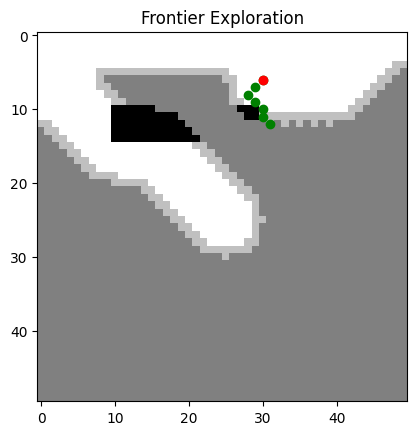

Step: 88
debugging position (10,15): 1
reveal map..
robot location: (29, 7)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (24, 5), (25, 5), (47, 5), (48, 5), (8, 6), (25, 6), (46, 6), (47, 6), (8, 7), (9, 7), (24, 7), (25, 7), (45, 7), (46, 7), (9, 8), (10, 8), (25, 8), (44, 8), (45, 8), (10, 9), (11, 9), (25, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20

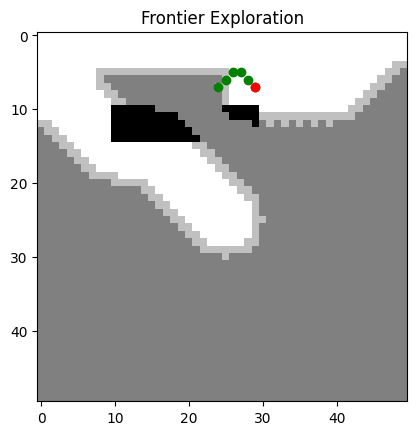

Step: 89
debugging position (10,15): 1
reveal map..
robot location: (28, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (47, 5), (48, 5), (8, 6), (23, 6), (24, 6), (46, 6), (47, 6), (8, 7), (9, 7), (24, 7), (45, 7), (46, 7), (9, 8), (10, 8), (24, 8), (44, 8), (45, 8), (10, 9), (11, 9), (24, 9), (25, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 2

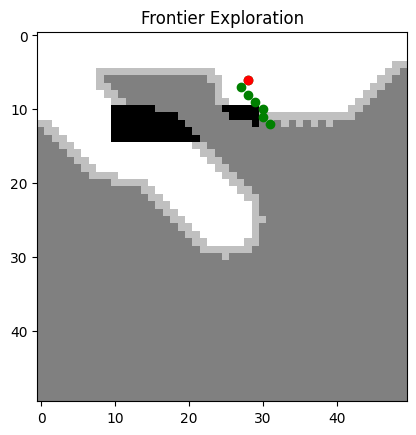

Step: 90
debugging position (10,15): 1
reveal map..
robot location: (27, 7)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (22, 5), (23, 5), (47, 5), (48, 5), (8, 6), (23, 6), (46, 6), (47, 6), (8, 7), (9, 7), (22, 7), (23, 7), (45, 7), (46, 7), (9, 8), (10, 8), (23, 8), (44, 8), (45, 8), (10, 9), (11, 9), (23, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 

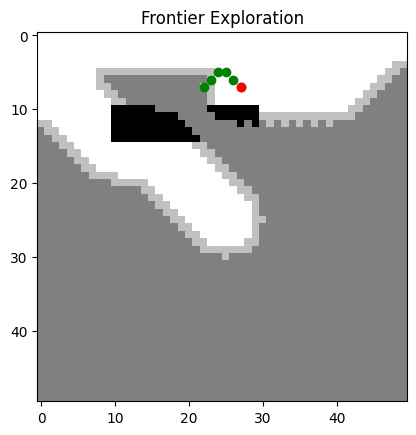

Step: 91
debugging position (10,15): 1
reveal map..
robot location: (26, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (21, 5), (47, 5), (48, 5), (8, 6), (21, 6), (22, 6), (46, 6), (47, 6), (8, 7), (9, 7), (22, 7), (45, 7), (46, 7), (9, 8), (10, 8), (22, 8), (44, 8), (45, 8), (10, 9), (11, 9), (22, 9), (23, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15,

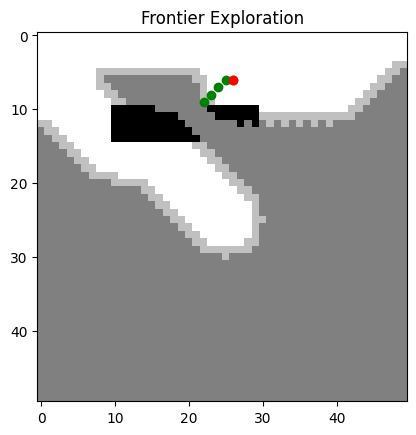

Step: 92
debugging position (10,15): 1
reveal map..
robot location: (25, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (20, 5), (47, 5), (48, 5), (8, 6), (20, 6), (21, 6), (46, 6), (47, 6), (8, 7), (9, 7), (21, 7), (45, 7), (46, 7), (9, 8), (10, 8), (21, 8), (44, 8), (45, 8), (10, 9), (11, 9), (21, 9), (22, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27

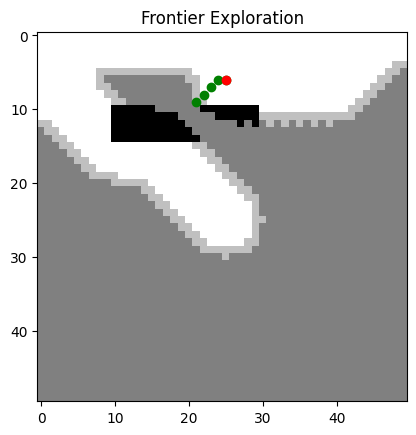

Step: 93
debugging position (10,15): 1
reveal map..
robot location: (24, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (19, 5), (47, 5), (48, 5), (8, 6), (19, 6), (20, 6), (46, 6), (47, 6), (8, 7), (9, 7), (20, 7), (45, 7), (46, 7), (9, 8), (10, 8), (20, 8), (44, 8), (45, 8), (10, 9), (11, 9), (20, 9), (21, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (2

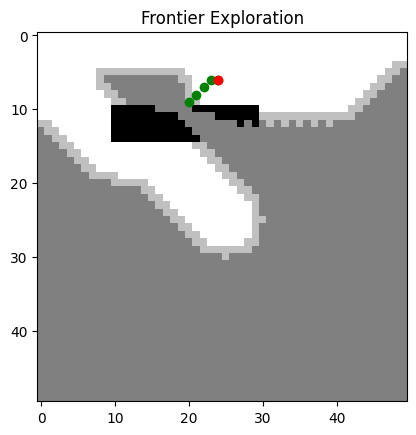

Step: 94
debugging position (10,15): 1
reveal map..
robot location: (23, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (18, 5), (47, 5), (48, 5), (8, 6), (18, 6), (19, 6), (46, 6), (47, 6), (8, 7), (9, 7), (19, 7), (45, 7), (46, 7), (9, 8), (10, 8), (19, 8), (44, 8), (45, 8), (10, 9), (11, 9), (19, 9), (20, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (

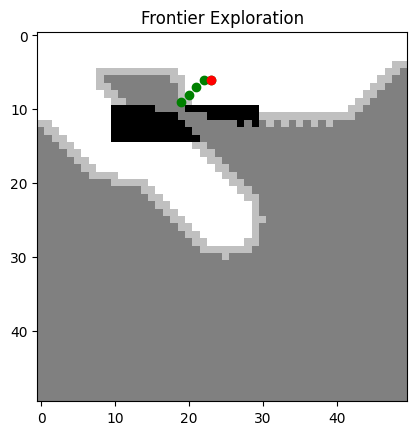

Step: 95
debugging position (10,15): 1
reveal map..
robot location: (22, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (17, 5), (47, 5), (48, 5), (8, 6), (17, 6), (18, 6), (46, 6), (47, 6), (8, 7), (9, 7), (18, 7), (45, 7), (46, 7), (9, 8), (10, 8), (18, 8), (44, 8), (45, 8), (10, 9), (11, 9), (18, 9), (19, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), 

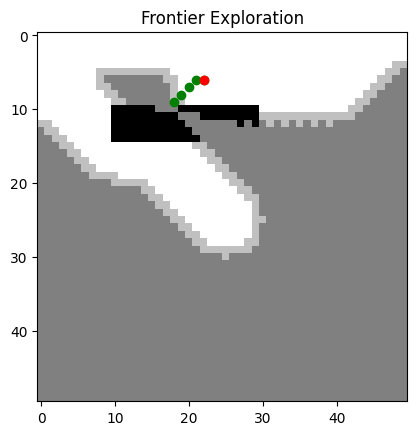

Step: 96
debugging position (10,15): 1
reveal map..
robot location: (21, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (16, 5), (47, 5), (48, 5), (8, 6), (16, 6), (17, 6), (46, 6), (47, 6), (8, 7), (9, 7), (17, 7), (45, 7), (46, 7), (9, 8), (10, 8), (17, 8), (44, 8), (45, 8), (10, 9), (11, 9), (17, 9), (18, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22),

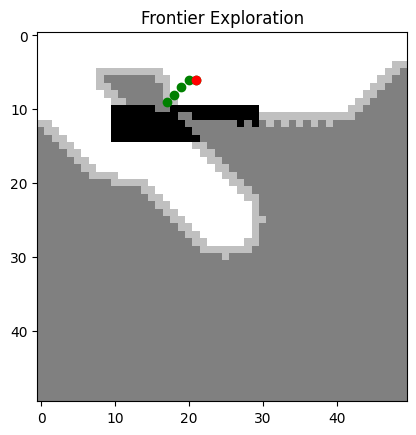

Step: 97
debugging position (10,15): 1
reveal map..
robot location: (20, 6)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (47, 5), (48, 5), (8, 6), (15, 6), (16, 6), (46, 6), (47, 6), (8, 7), (9, 7), (16, 7), (45, 7), (46, 7), (9, 8), (10, 8), (16, 8), (44, 8), (45, 8), (10, 9), (11, 9), (16, 9), (17, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22)

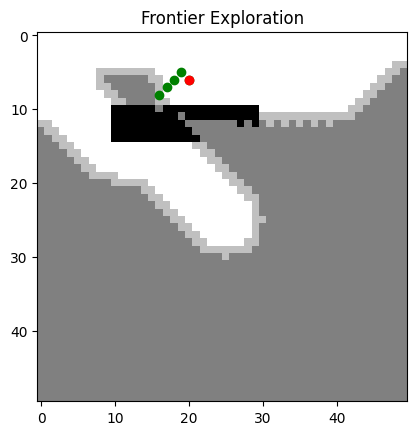

Step: 98
debugging position (10,15): 1
reveal map..
robot location: (19, 5)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (15, 5), (47, 5), (48, 5), (8, 6), (15, 6), (46, 6), (47, 6), (8, 7), (9, 7), (15, 7), (45, 7), (46, 7), (9, 8), (10, 8), (15, 8), (16, 8), (44, 8), (45, 8), (10, 9), (11, 9), (16, 9), (17, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22)

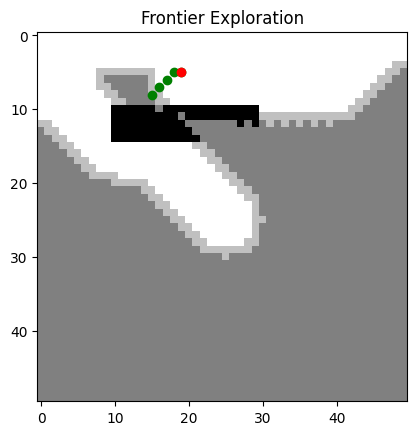

Step: 99
debugging position (10,15): 1
reveal map..
robot location: (18, 5)
map shape: (50, 50)
frontiers: [(48, 4), (49, 4), (8, 5), (9, 5), (10, 5), (11, 5), (12, 5), (13, 5), (14, 5), (47, 5), (48, 5), (8, 6), (14, 6), (46, 6), (47, 6), (8, 7), (9, 7), (14, 7), (45, 7), (46, 7), (9, 8), (10, 8), (14, 8), (15, 8), (44, 8), (45, 8), (10, 9), (11, 9), (15, 9), (16, 9), (17, 9), (43, 9), (44, 9), (42, 10), (43, 10), (30, 11), (31, 11), (32, 11), (33, 11), (34, 11), (35, 11), (36, 11), (37, 11), (38, 11), (39, 11), (40, 11), (41, 11), (42, 11), (0, 12), (1, 12), (31, 12), (33, 12), (35, 12), (37, 12), (39, 12), (1, 13), (2, 13), (2, 14), (3, 14), (3, 15), (4, 15), (21, 15), (22, 15), (4, 16), (5, 16), (22, 16), (23, 16), (5, 17), (6, 17), (23, 17), (24, 17), (6, 18), (7, 18), (24, 18), (25, 18), (7, 19), (8, 19), (9, 19), (10, 19), (25, 19), (26, 19), (10, 20), (11, 20), (12, 20), (13, 20), (14, 20), (26, 20), (27, 20), (14, 21), (15, 21), (27, 21), (28, 21), (15, 22), (16, 22), (28, 22)

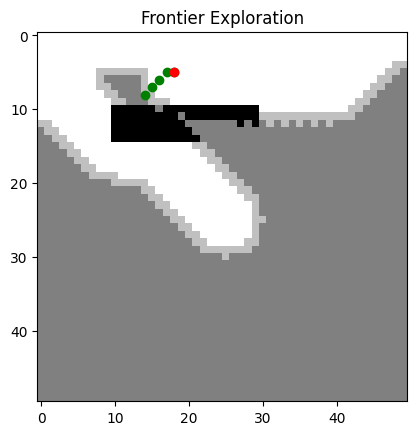

In [ ]:
world = create_world()
map_belief = init_map()

plt.imshow(world, cmap='gray')
plt.show()

robot = (25, 25)

for step in range(100):
    print("Step:", step)
    print(f"debugging position (10,15): {map_belief[10,15]}")

    # 1. Reveal environment
    print("reveal map..")
    print(f"robot location: {robot}")
    map_belief = reveal(map_belief, world, robot)
    # if robot[0] > 45: x = 45
    # elif robot[0] < 5: x = 5
    # else: x = robot[0]
    # if robot[1] > 45: y = 45
    # elif robot[1] < 5: y = 5
    # else: y = robot[1]
    x = robot[0]
    y = robot[1]
    # print(f"map_belief at robot position: {map_belief[y,x]}")

    # 2. Get frontiers
    frontiers = get_frontiers(map_belief)
    print(f"frontiers: {frontiers}")

    # 4. Move robot using exploration_step (Dijkstra inside)
    next_pos, path = exploration_step(map_belief, robot)
    print(f"target position: {next_pos}")

    # 3. Show current state
    show(map_belief, robot, frontiers, path)

    if next_pos is None:
        break

    # Update robot's position to the last point in the path
    robot = next_pos